In this notebook we will import a model trained on the OpenDPD dataset and perform neural network pruning using a range of inverse models.

In [19]:
from sparseDPD import PGJANET_NeuralNetwork, PNTDNN_NeuralNetwork, ARVTDNN_NeuralNetwork
from sparseDPD import DataManager, Datapath, DatapathPruningExperiment, AdaptiveDatapathPruningExperiment

# load the OpenDPD dataset
# Same dataset/training style as refactored_notebook.ipynb
openDPD_folder = '../OpenDPD_datasets/DPA_160MHz'

#40,000 points
openDPD_dataManager = DataManager(
    num_test_points=98304,
    num_training_points=294912,
    num_validaiton_points=98304,
    openDPD_test_input_file=f'{openDPD_folder}/test_input.csv',
    openDPD_test_output_file=f'{openDPD_folder}/test_output.csv',
    openDPD_training_input_file=f'{openDPD_folder}/train_input.csv',
    openDPD_training_output_file=f'{openDPD_folder}/train_output.csv',
    openDPD_validation_input_file=f'{openDPD_folder}/val_input.csv',
    openDPD_validation_output_file=f'{openDPD_folder}/val_output.csv'
)

# Evaluate model performance before pruning
openDPD_fs = 640e6  # Sampling frequency: 640 MHz
openDPD_bw_main_ch = 160e6  # Main channel bandwidth: 160 MHz
openDPD_bw_sub_ch = 40e6  # Sub-channel bandwidth: 40 MHz
openDPD_n_sub_ch = 4  # Number of sub-channels
openDPD_nperseg = 16384  # FFT size (frame length)

# Load forward model
PNTDNN_three_layer_forward_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='ThreeLayerNetwork', nn_file_path='../open_dpd_DPA_160MHz_forward_models/pntdnn_three_layer_open.pt')

Using cuda device


# PNTDNN one layer

In [7]:
# Train an inverse model based on this forward model
# Instantiate a new PNTDNN model for training (one layer)

PNTDNN_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path=None, forward_model=False)
# Create a datapath with this model and the forward model
datapath_pntdnn_one_layer = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=PNTDNN_inverse_nn)

datapath_pntdnn_one_layer.train_using_ila(
    training_dataset = openDPD_dataManager.training_dataset,
    valid_dataset = openDPD_dataManager.validation_dataset,
    iterations = 25,
    retrain_epochs_per_iteration=50,
    seq_length=None
)

# find nmse
nmse = datapath_pntdnn_one_layer.calculate_nmse(openDPD_dataManager.test_dataset.input_data)
print(f"NMSE: {nmse:.4f} dB")

# Plot the spectrum 
datapath_pntdnn_one_layer.plot_spectrum(openDPD_dataManager.test_dataset.input_data[:5000])

Using cuda device


KeyboardInterrupt: 

In [12]:
# Save inverse model
PNTDNN_inverse_nn.write_nn_to_file('pntdnn_inverse_model_open.pt')

Using cuda device
Raw PA Output (no DPD):
Total subcarriers (1 carrier): 1024, Active (after guard band filtering): 982


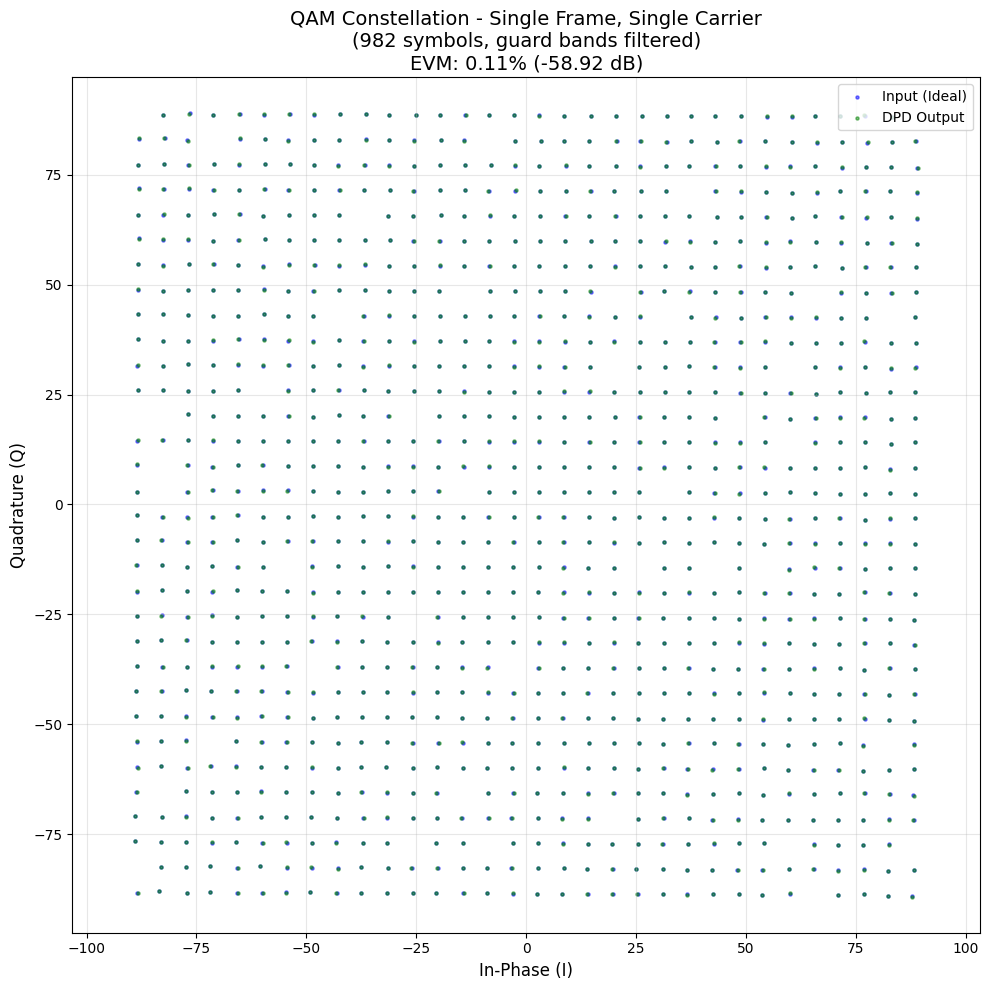

EVM (RMS): 0.113%
EVM (dB): -58.921 dB


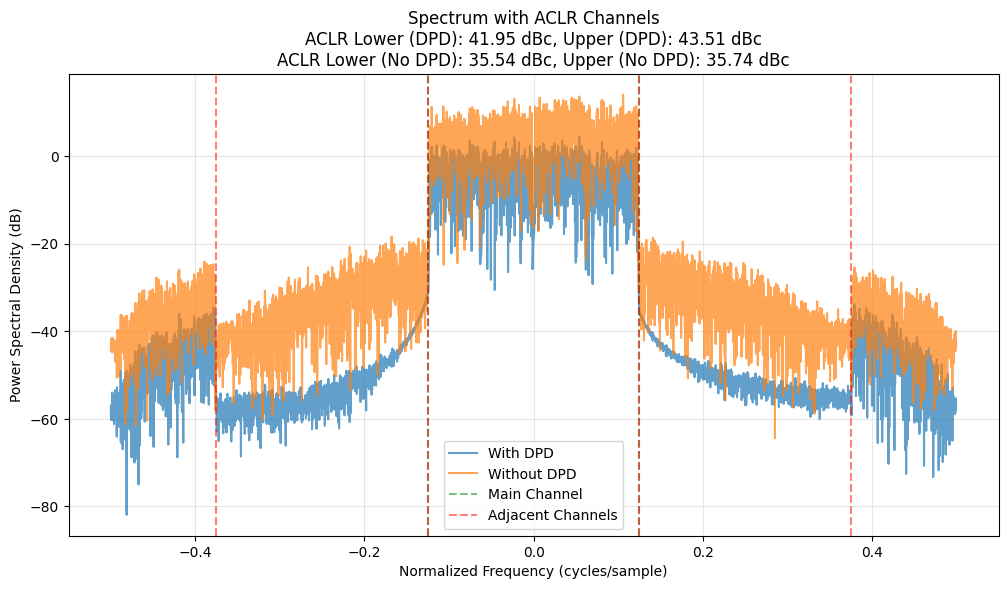

NMSE: (No DPD) 5.7197 dB
NMSE: -53.4779 dB


In [20]:
PNTDNN_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path='pntdnn_inverse_model_open.pt', forward_model=False)
datapath_pntdnn_one_layer = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=PNTDNN_inverse_nn)

# Evaluate model performance before pruning
openDPD_fs = 640e6  # Sampling frequency: 640 MHz
openDPD_bw_main_ch = 160e6  # Main channel bandwidth: 160 MHz
openDPD_bw_sub_ch = 40e6  # Sub-channel bandwidth: 40 MHz
openDPD_n_sub_ch = 4  # Number of sub-channels
openDPD_nperseg = 16384  # FFT size (frame length)

# Plot the QAM constellation - First check raw PA output (should be distorted)
print("Raw PA Output (no DPD):")
datapath_pntdnn_one_layer.plot_constellation(openDPD_dataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)

datapath_pntdnn_one_layer.plot_spectrum_with_aclr(
    openDPD_dataManager.test_dataset.input_data[:5000],
    channel_bw=0.25,
    channel_spacing=0.25
)

print(f"NMSE: (No DPD) {openDPD_dataManager.test_dataset.calculate_nmse():.4f} dB")
print(f"NMSE: {datapath_pntdnn_one_layer.calculate_nmse(openDPD_dataManager.training_dataset.input_data):.4f} dB")


Pruning Iteration 1/10
Pruning 20.0% of remaining weights...
Current pruning: 20.00% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=2.5117e-02  Valid Loss=2.4077e+01  LR=1.00e-03
Epoch  20/100  Loss=2.3639e-02  Valid Loss=2.3123e+01  LR=1.00e-03
Epoch  30/100  Loss=2.1296e-02  Valid Loss=2.2950e+01  LR=1.00e-03
Epoch  40/100  Loss=1.8212e-02  Valid Loss=2.2770e+01  LR=5.00e-04
Epoch  50/100  Loss=1.8090e-02  Valid Loss=2.2728e+01  LR=5.00e-04
Epoch  60/100  Loss=1.8196e-02  Valid Loss=2.2471e+01  LR=5.00e-04
Epoch  70/100  Loss=1.8275e-02  Valid Loss=2.2508e+01  LR=5.00e-04
Epoch  80/100  Loss=1.7650e-02  Valid Loss=2.2687e+01  LR=2.50e-04
Epoch  90/100  Loss=1.7431e-02  Valid Loss=2.2634e+01  LR=1.25e-04
Epoch 100/100  Loss=1.7342e-02  Valid Loss=2.2628e+01  LR=6.25e-05

Best model from epoch 60 with validation loss: 2.2471e+01
Iteration 1/1 (Block 1/1, samples 0-294912) - NMSE: -52.4009 dB
--------------------------------------------------
NMSE: -52.3471 dB

Pr

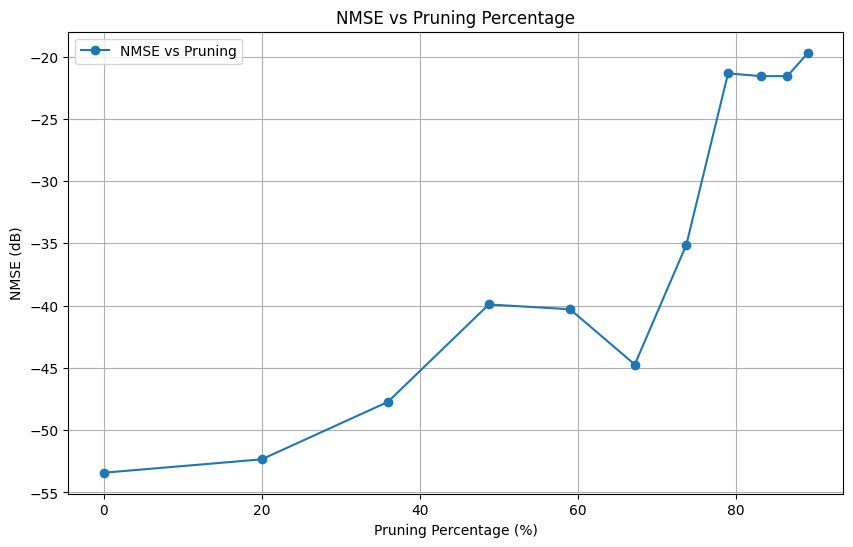

In [ ]:
# Now prune the inverse model and evaluate performance again
pruning_experiment_pntdnn_one_layer = DatapathPruningExperiment(
    datapath=datapath_pntdnn_one_layer,
    training_dataset=openDPD_dataManager.training_dataset,
    validation_dataset=openDPD_dataManager.validation_dataset,
    test_dataset=openDPD_dataManager.test_dataset,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=100,
    ila_iterations=3,
    nmse_tolerance=-40,
    seq_length=None
)

pruning_experiment_pntdnn_one_layer.run()

# Save the best linear pruned inverse DatapathPruningExperimentmodel
pruning_experiment_pntdnn_one_layer.best_datapath.inverse_model.write_nn_to_file('pntdnn_one_layer_fixed_percentage_pruned_inverse_model_open.pt')


Using cuda device
Sparsity of pruned model: 0.00%
Total subcarriers (1 carrier): 1024, Active (after guard band filtering): 982


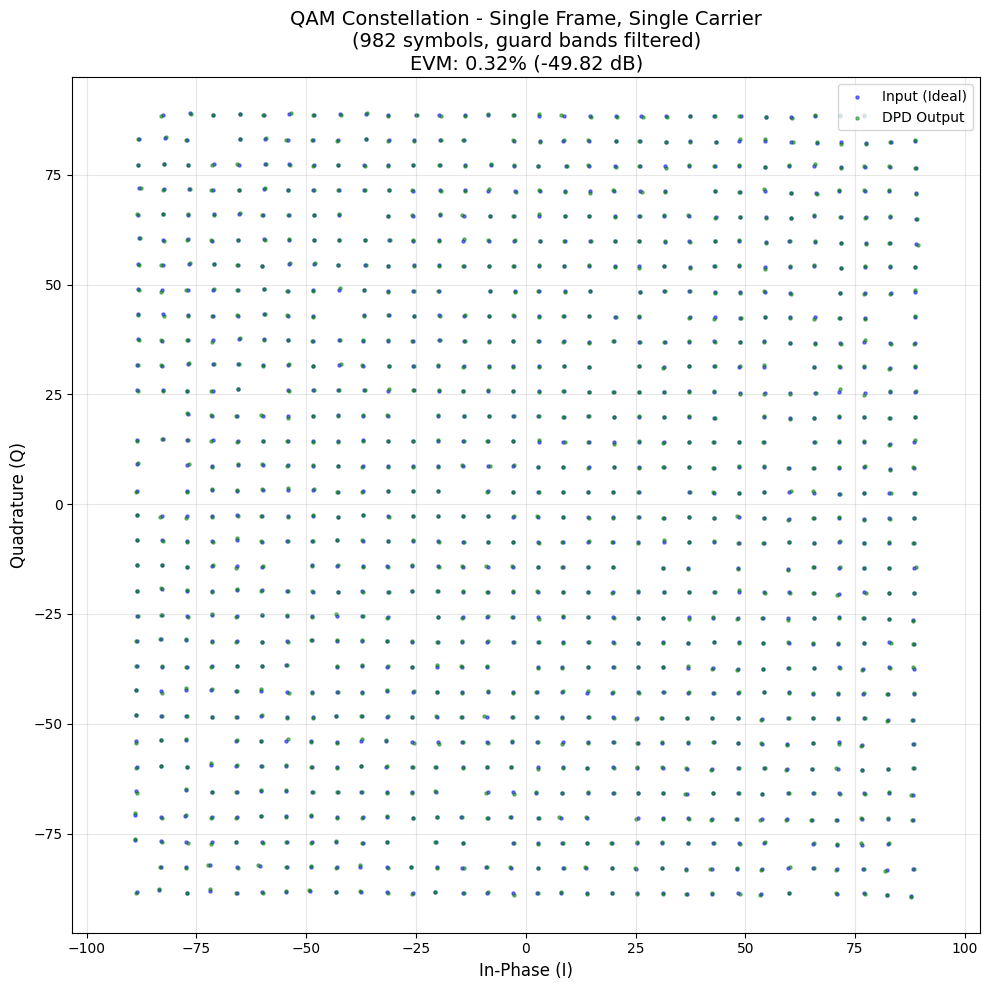

EVM (RMS): 0.323%
EVM (dB): -49.818 dB


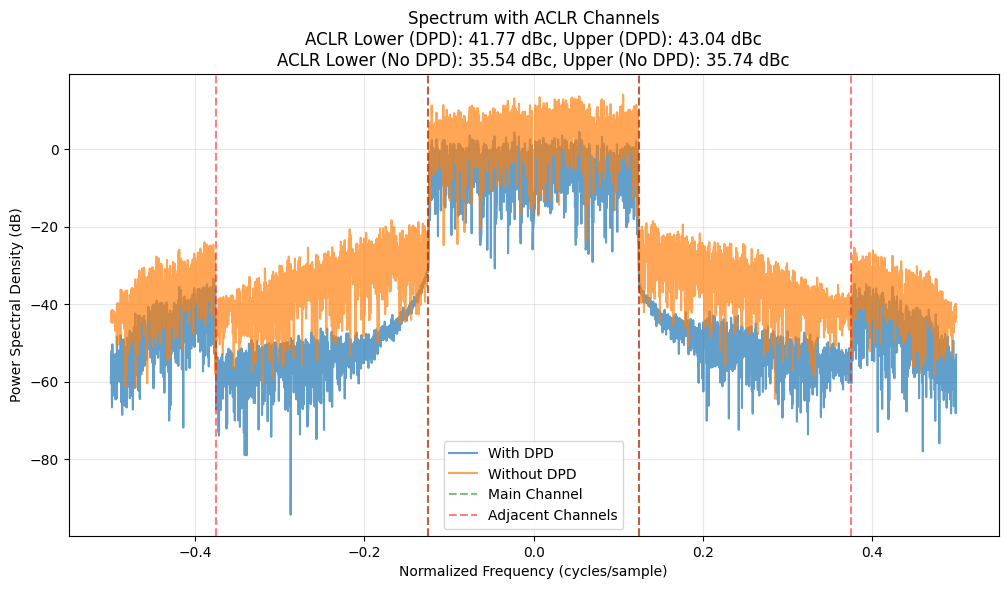

In [15]:
# Load best linear pruned model and evaluate performance
best_pruned_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path='pntdnn_one_layer_fixed_percentage_pruned_inverse_model_open.pt', forward_model=False)
#print sparsity of pruned model
print(f"Sparsity of pruned model: {best_pruned_inverse_nn._get_pruning_percentage():.2f}%")

best_pruned_datapath = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=best_pruned_inverse_nn)
# Plots for of best model
best_pruned_datapath.plot_constellation(openDPD_dataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)
best_pruned_datapath.plot_spectrum_with_aclr(openDPD_dataManager.test_dataset.input_data[:5000], channel_bw=0.25, channel_spacing=0.25)


Step 1  |  fraction = 50.00%
Pruning 50.00% of remaining weights...
Current sparsity: 50.00% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=1.8227e-01  Valid Loss=2.2284e+01  LR=1.00e-03
Epoch  20/100  Loss=9.9897e-02  Valid Loss=1.3346e+01  LR=1.00e-03
Epoch  30/100  Loss=8.3310e-02  Valid Loss=1.2625e+01  LR=1.00e-03
Epoch  40/100  Loss=7.7235e-02  Valid Loss=1.3348e+01  LR=5.00e-04
Epoch  50/100  Loss=7.5302e-02  Valid Loss=1.3939e+01  LR=2.50e-04
Epoch  60/100  Loss=7.4641e-02  Valid Loss=1.4376e+01  LR=1.25e-04
Epoch  70/100  Loss=7.4094e-02  Valid Loss=1.4628e+01  LR=1.25e-04
Epoch  80/100  Loss=7.3814e-02  Valid Loss=1.4821e+01  LR=6.25e-05
Epoch  90/100  Loss=7.3609e-02  Valid Loss=1.4946e+01  LR=3.13e-05
Epoch 100/100  Loss=7.3493e-02  Valid Loss=1.5020e+01  LR=1.56e-05

Best model from epoch 27 with validation loss: 1.2562e+01
Iteration 1/3 (Block 1/1, samples 0-294912) - NMSE: -47.1727 dB
--------------------------------------------------
Epoch  10/100

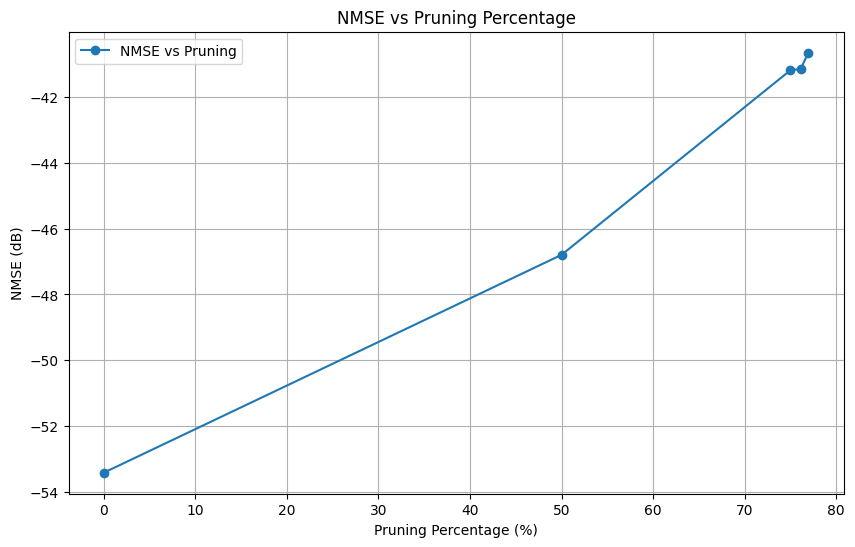

Best NMSE after pruning: -40.6471 dB


In [24]:
# Now try an adaptive pruning approach


adaptive_pruning_experiment = AdaptiveDatapathPruningExperiment(
    datapath=datapath_pntdnn_one_layer,
    training_dataset=openDPD_dataManager.training_dataset,
    validation_dataset=openDPD_dataManager.validation_dataset,
    test_dataset=openDPD_dataManager.test_dataset,
    retrain_epochs=100,
    ila_iterations = 3,
    initial_prune_fraction=0.5,
    max_prune_fraction=0.5,
    min_prune_fraction=0.01,
    nmse_tolerance=13.4779
)

adaptive_pruning_experiment.run()

print("Best NMSE after pruning: {:.4f} dB".format(adaptive_pruning_experiment.best_datapath.calculate_nmse(openDPD_dataManager.test_dataset.input_data)))

pntdnn_best_adaptive_pruned_model = adaptive_pruning_experiment.best_datapath.inverse_model
pntdnn_best_adaptive_pruned_model.write_nn_to_file('pntdnn_one_layer_adaptive_pruned_inverse_model_open.pt')

Using cuda device
Total subcarriers (1 carrier): 1024, Active (after guard band filtering): 982


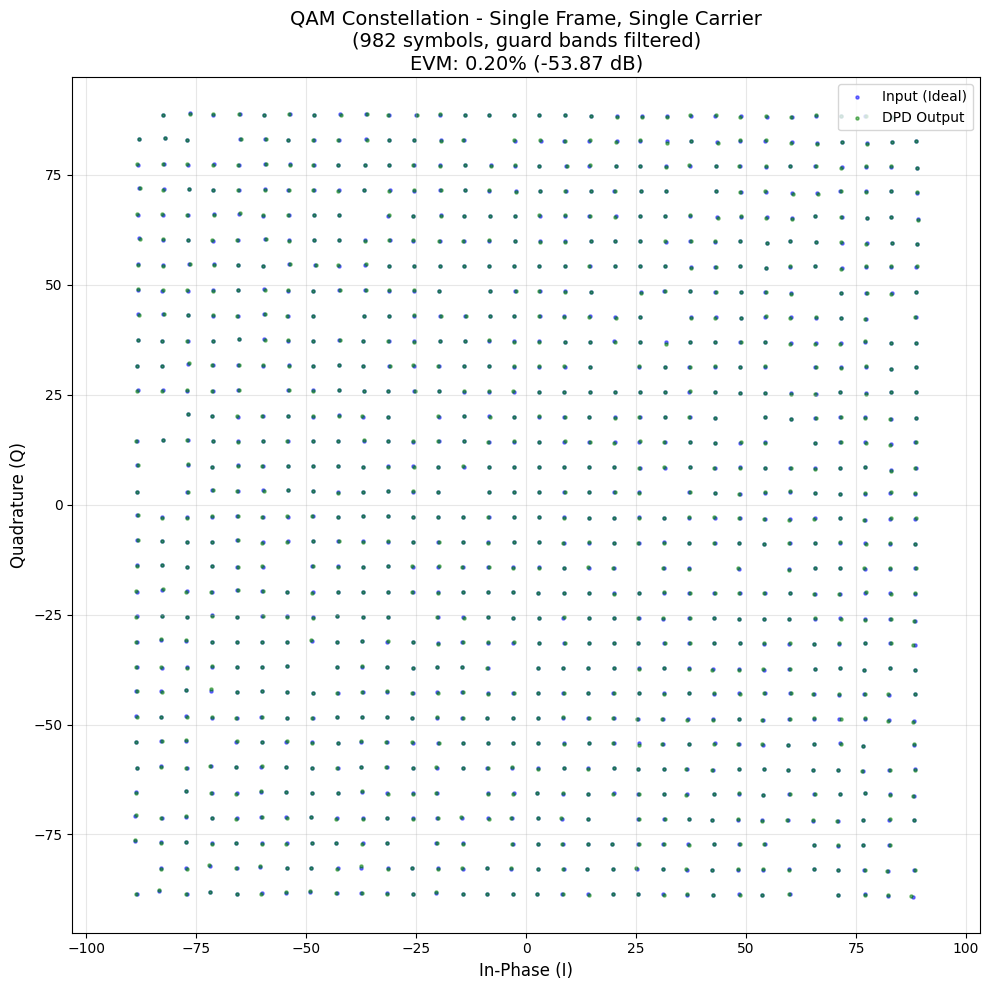

EVM (RMS): 0.203%
EVM (dB): -53.867 dB


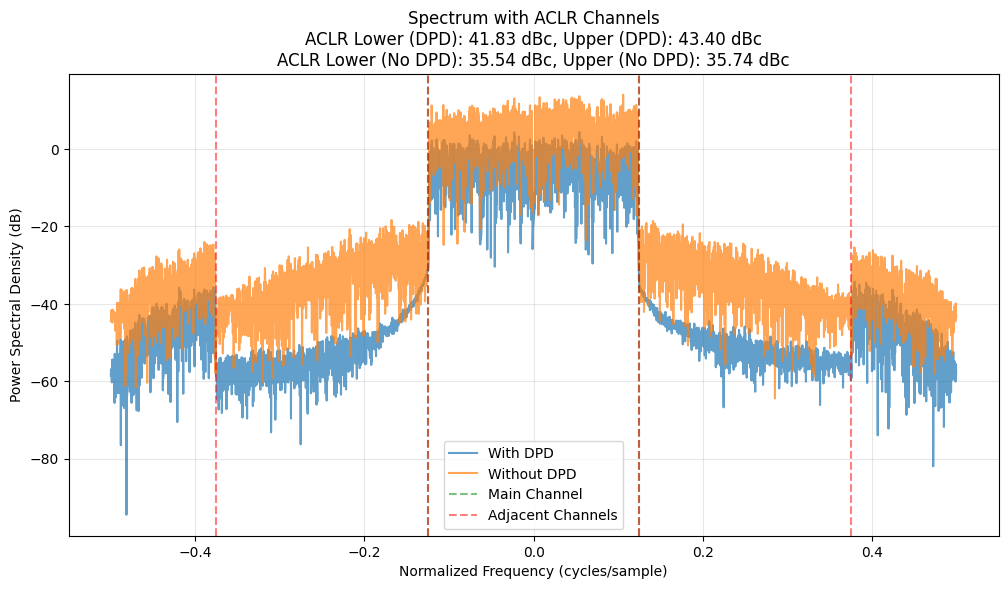

In [22]:
# load the adaptive best, and find its performance
best_adaptive_pruned_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path='pntdnn_one_layer_adaptive_pruned_inverse_model_open.pt', forward_model=False)
best_adaptive_pruned_datapath = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=best_adaptive_pruned_inverse_nn)
best_adaptive_pruned_datapath.plot_constellation(openDPD_dataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)
best_adaptive_pruned_datapath.plot_spectrum_with_aclr(openDPD_dataManager.test_dataset.input_data[:5000], channel_bw=0.25, channel_spacing=0.25)

# PG-JANET one layer

Using cuda device
Epoch  10/50  Loss=7.2412e-03  Valid Loss=3.2822e+03  LR=1.00e-03
Epoch  20/50  Loss=4.4013e-03  Valid Loss=3.0621e+03  LR=5.00e-04
Epoch  30/50  Loss=3.3518e-03  Valid Loss=2.4795e+03  LR=5.00e-04
Epoch  40/50  Loss=2.7540e-03  Valid Loss=2.3056e+03  LR=5.00e-04
Epoch  50/50  Loss=2.5302e-03  Valid Loss=2.2795e+03  LR=5.00e-04

Best model from epoch 50 with validation loss: 2.2795e+03
Iteration 1/10 (Block 1/1, samples 0-294912) - NMSE: -6.9421 dB
--------------------------------------------------
Epoch  10/50  Loss=2.6908e-01  Valid Loss=2.2781e+02  LR=1.00e-03
Epoch  20/50  Loss=2.1810e-01  Valid Loss=1.8093e+02  LR=1.00e-03
Epoch  30/50  Loss=1.9716e-01  Valid Loss=1.7356e+02  LR=1.00e-03
Epoch  40/50  Loss=1.8839e-01  Valid Loss=1.7760e+02  LR=1.00e-03
Epoch  50/50  Loss=1.7422e-01  Valid Loss=1.8574e+02  LR=5.00e-04

Best model from epoch 32 with validation loss: 1.7101e+02
Iteration 2/10 (Block 1/1, samples 0-294912) - NMSE: -25.2435 dB
------------------------

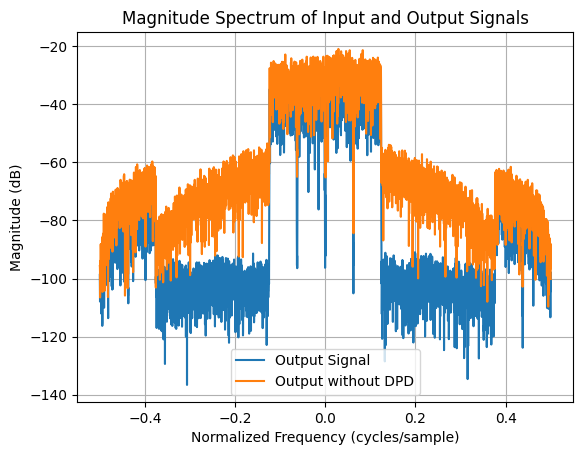

In [8]:
# Train an inverse model based on this forward model
# Instantiate a new PG-JANET model for training (one layer)

PGJANET_inverse_nn = PGJANET_NeuralNetwork(num_memory_levels=15, model_type='PGJANETNetwork', nn_file_path=None, forward_model=False, batch_size=512, hidden_size=16)
# Create a datapath with this model and the forward model
datapath_pgjanet_one_layer = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=PGJANET_inverse_nn)

datapath_pgjanet_one_layer.train_using_ila(
    training_dataset = openDPD_dataManager.training_dataset,
    valid_dataset = openDPD_dataManager.validation_dataset,
    iterations = 10,
    retrain_epochs_per_iteration=50,
    seq_length=None
)

# find nmse
nmse = datapath_pgjanet_one_layer.calculate_nmse(openDPD_dataManager.test_dataset.input_data)
print(f"NMSE: {nmse:.4f} dB")

# Plot the spectrum 
datapath_pgjanet_one_layer.plot_spectrum(openDPD_dataManager.test_dataset.input_data[:5000])

In [9]:
# Save inverse model
PGJANET_inverse_nn.write_nn_to_file('pgjanet_inverse_model_open.pt')

Using cuda device
Raw PA Output (no DPD):
Total subcarriers (1 carrier): 1024, Active (after guard band filtering): 982


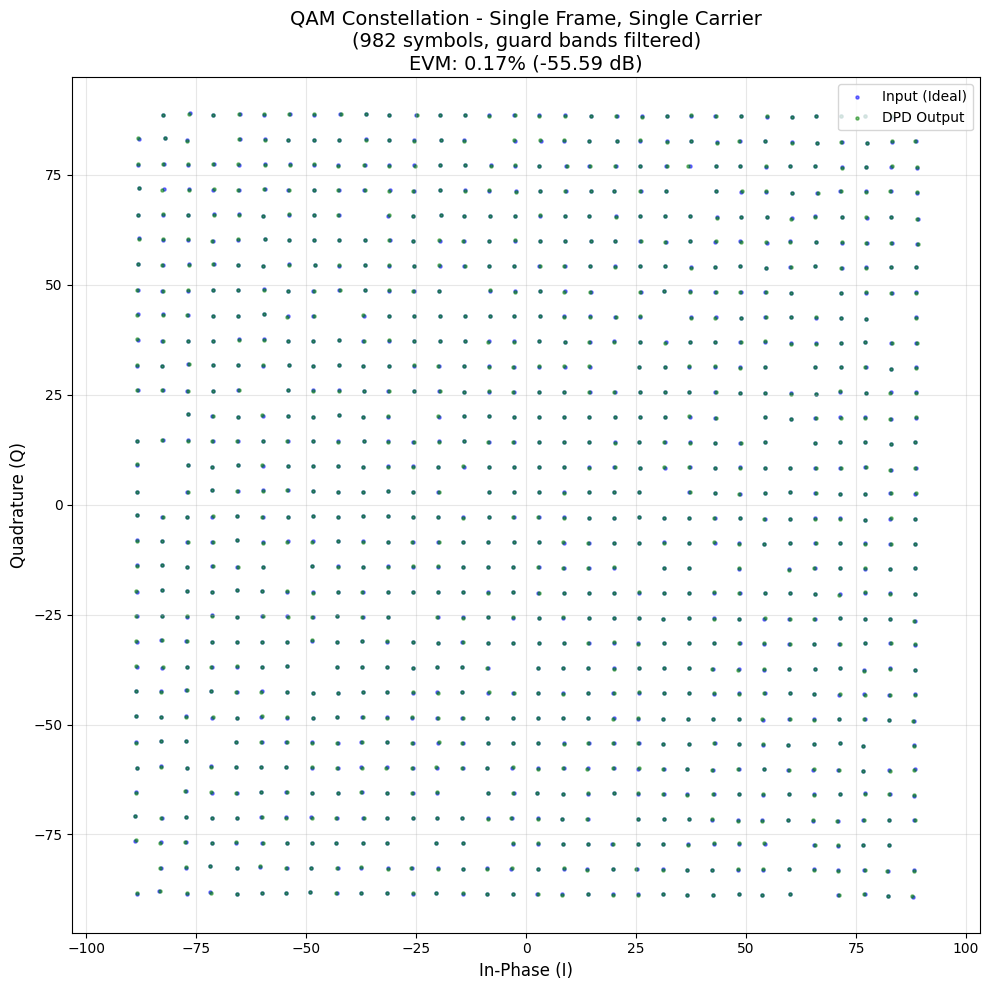

EVM (RMS): 0.166%
EVM (dB): -55.589 dB


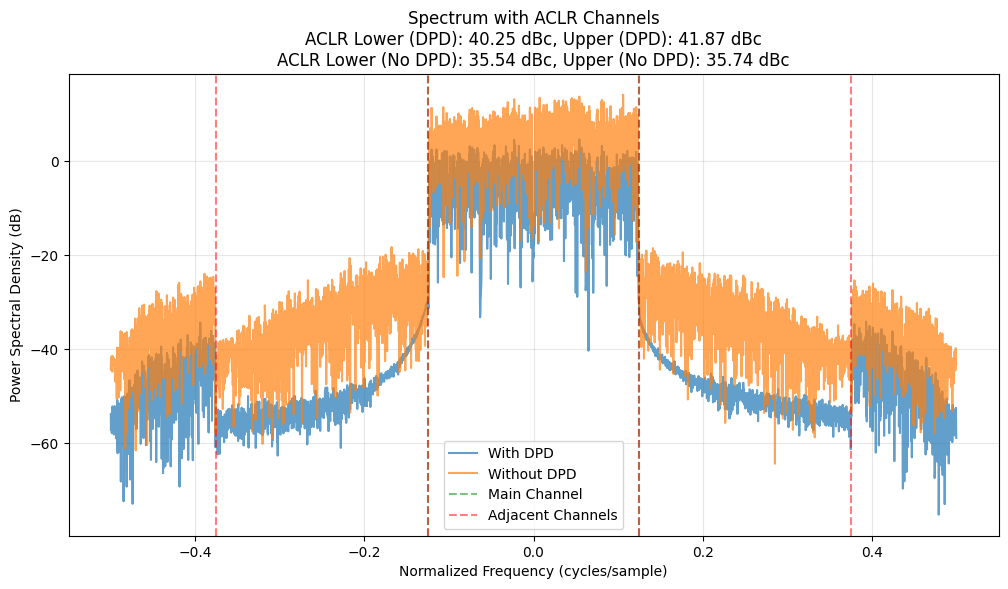

NMSE: (No DPD) 5.7197 dB
NMSE: -51.4635 dB


In [10]:
PGJANET_inverse_nn = PGJANET_NeuralNetwork(num_memory_levels=15, model_type='PGJANETNetwork', nn_file_path='pgjanet_inverse_model_open.pt', forward_model=False)
datapath_pgjanet_one_layer = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=PGJANET_inverse_nn)

# Evaluate model performance before pruning
openDPD_fs = 640e6  # Sampling frequency: 640 MHz
openDPD_bw_main_ch = 160e6  # Main channel bandwidth: 160 MHz
openDPD_bw_sub_ch = 40e6  # Sub-channel bandwidth: 40 MHz
openDPD_n_sub_ch = 4  # Number of sub-channels
openDPD_nperseg = 16384  # FFT size (frame length)

# Plot the QAM constellation - First check raw PA output (should be distorted)
print("Raw PA Output (no DPD):")
datapath_pgjanet_one_layer.plot_constellation(openDPD_dataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)

datapath_pgjanet_one_layer.plot_spectrum_with_aclr(
    openDPD_dataManager.test_dataset.input_data[:5000],
    channel_bw=0.25,
    channel_spacing=0.25
)

print(f"NMSE: (No DPD) {openDPD_dataManager.test_dataset.calculate_nmse():.4f} dB")
print(f"NMSE: {datapath_pgjanet_one_layer.calculate_nmse(openDPD_dataManager.test_dataset.input_data):.4f} dB")


Pruning Iteration 1/10
Pruning 20.0% of remaining weights...
Current pruning: 19.98% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=2.1934e-02  Valid Loss=1.0920e+01  LR=1.00e-03
Epoch  20/100  Loss=2.0771e-02  Valid Loss=1.1036e+01  LR=1.00e-03
Epoch  30/100  Loss=1.7069e-02  Valid Loss=1.1555e+01  LR=5.00e-04
Epoch  40/100  Loss=1.5310e-02  Valid Loss=1.1457e+01  LR=2.50e-04
Epoch  50/100  Loss=1.4449e-02  Valid Loss=1.1567e+01  LR=1.25e-04
Epoch  60/100  Loss=1.4073e-02  Valid Loss=1.1507e+01  LR=6.25e-05
Epoch  70/100  Loss=1.3802e-02  Valid Loss=1.1495e+01  LR=3.13e-05
Epoch  80/100  Loss=1.3813e-02  Valid Loss=1.1523e+01  LR=1.56e-05
Epoch  90/100  Loss=1.3689e-02  Valid Loss=1.1455e+01  LR=1.56e-05
Epoch 100/100  Loss=1.3614e-02  Valid Loss=1.1443e+01  LR=7.81e-06

Best model from epoch 14 with validation loss: 1.0701e+01
Iteration 1/1 (Block 1/1, samples 0-294912) - NMSE: -46.2036 dB
--------------------------------------------------
NMSE: -46.0733 dB

Pr

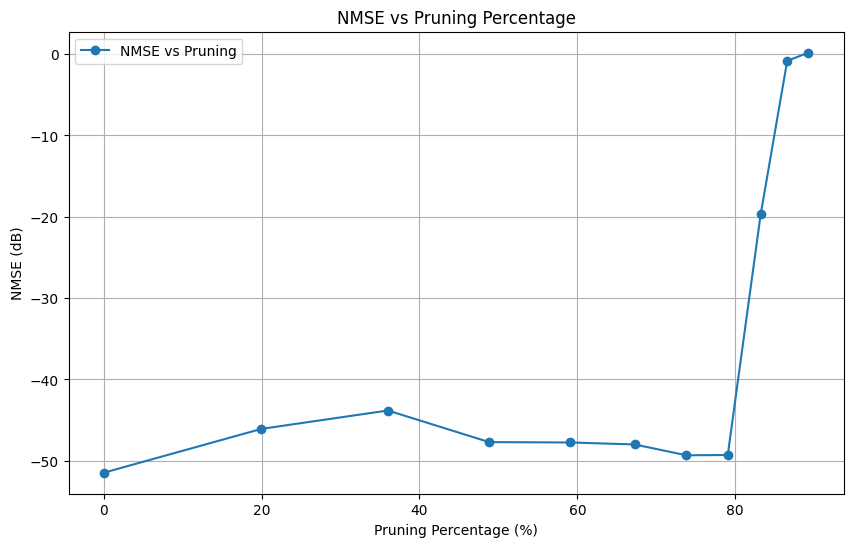

In [11]:
# Now prune the inverse model and evaluate performance again
pruning_experiment_pgjanet_one_layer = DatapathPruningExperiment(
    datapath=datapath_pgjanet_one_layer,
    training_dataset=openDPD_dataManager.training_dataset,
    validation_dataset=openDPD_dataManager.validation_dataset,
    test_dataset=openDPD_dataManager.test_dataset,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=100,
    ila_iterations=1,
    nmse_tolerance=-40,
    seq_length=None
)

pruning_experiment_pgjanet_one_layer.run()

# Save the best linear pruned inverse model
pruning_experiment_pgjanet_one_layer.best_datapath.inverse_model.write_nn_to_file('pgjanet_one_layer_fixed_percentage_pruned_inverse_model_open.pt')

Using cuda device
Sparsity of pruned model: 0.00%
Total subcarriers (1 carrier): 1024, Active (after guard band filtering): 982


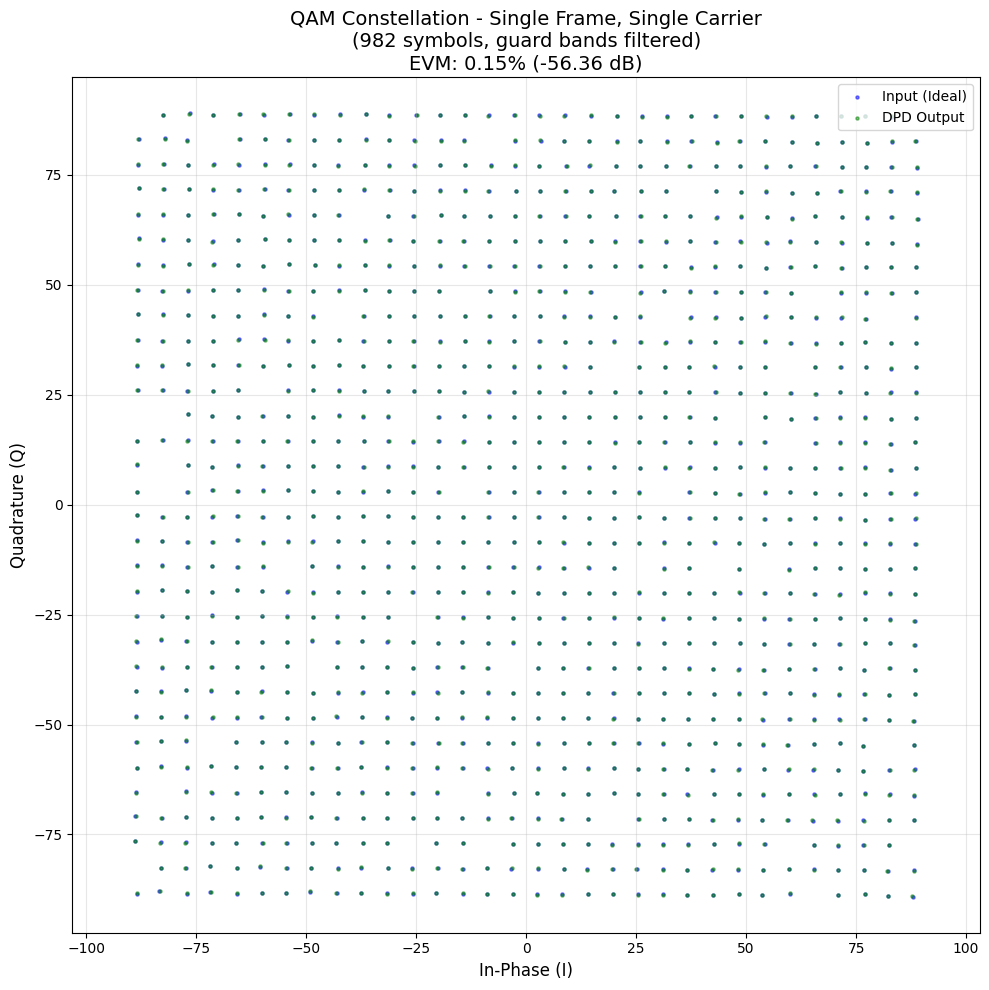

EVM (RMS): 0.152%
EVM (dB): -56.364 dB


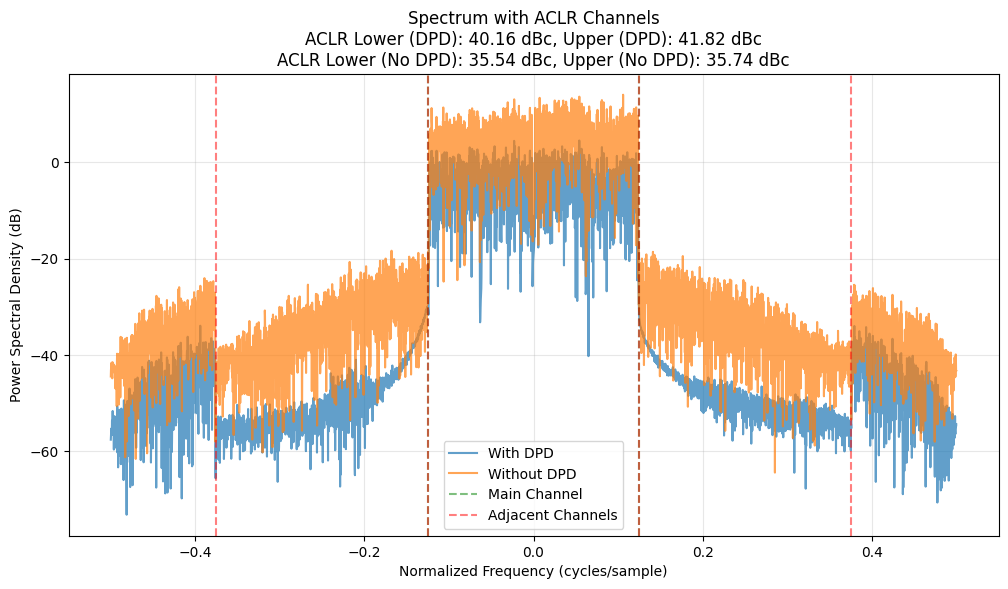

NMSE of best pruned PG-JANET model: -49.2838 dB


In [13]:
# Load best linear pruned model and evaluate performance
best_pruned_pgjanet_inverse_nn = PGJANET_NeuralNetwork(num_memory_levels=15, model_type='PGJANETNetwork', nn_file_path='pgjanet_one_layer_fixed_percentage_pruned_inverse_model_open.pt', forward_model=False)
#print sparsity of pruned model
print(f"Sparsity of pruned model: {best_pruned_pgjanet_inverse_nn._get_pruning_percentage():.2f}%")

best_pruned_pgjanet_datapath = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=best_pruned_pgjanet_inverse_nn)
# Plots for of best model
best_pruned_pgjanet_datapath.plot_constellation(openDPD_dataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)
best_pruned_pgjanet_datapath.plot_spectrum_with_aclr(openDPD_dataManager.test_dataset.input_data[:5000], channel_bw=0.25, channel_spacing=0.25)

# Print NMSE of best pruned model
print(f"NMSE of best pruned PG-JANET model: {best_pruned_pgjanet_datapath.calculate_nmse(openDPD_dataManager.test_dataset.input_data):.4f} dB")


Step 1  |  fraction = 20.00%
Pruning 20.00% of remaining weights...
Current sparsity: 19.98% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=2.1572e-02  Valid Loss=1.0756e+01  LR=1.00e-03
Epoch  20/100  Loss=2.0854e-02  Valid Loss=1.1119e+01  LR=1.00e-03
Epoch  30/100  Loss=1.6868e-02  Valid Loss=1.1519e+01  LR=5.00e-04
Epoch  40/100  Loss=1.5423e-02  Valid Loss=1.1470e+01  LR=2.50e-04
Epoch  50/100  Loss=1.4544e-02  Valid Loss=1.1451e+01  LR=1.25e-04
Epoch  60/100  Loss=1.4166e-02  Valid Loss=1.1300e+01  LR=6.25e-05
Epoch  70/100  Loss=1.3930e-02  Valid Loss=1.1416e+01  LR=3.13e-05
Epoch  80/100  Loss=1.3795e-02  Valid Loss=1.1386e+01  LR=1.56e-05
Epoch  90/100  Loss=1.3725e-02  Valid Loss=1.1354e+01  LR=7.81e-06
Epoch 100/100  Loss=1.3687e-02  Valid Loss=1.1333e+01  LR=3.91e-06

Best model from epoch 10 with validation loss: 1.0756e+01
Iteration 1/1 (Block 1/1, samples 0-294912) - NMSE: -47.7846 dB
--------------------------------------------------
NMSE: -47.588

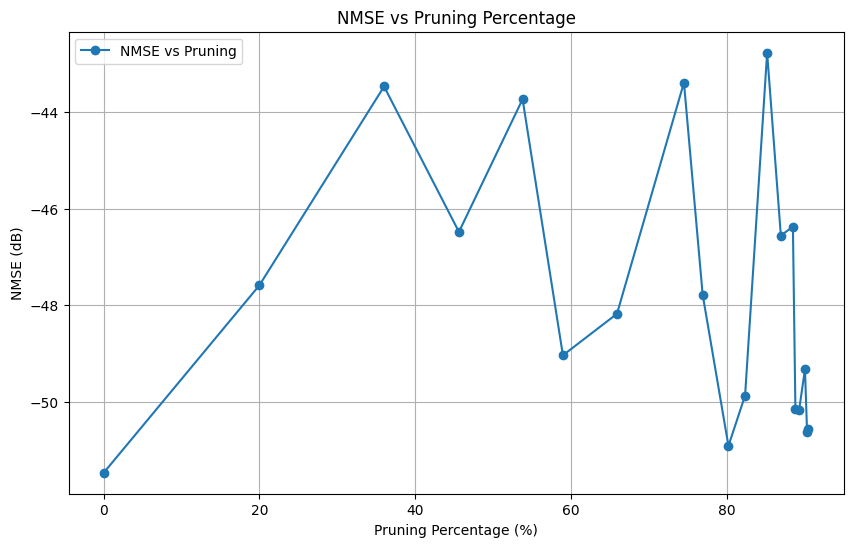

Best NMSE after pruning: -50.5584 dB


In [15]:
# Now try an adaptive pruning approach


adaptive_pruning_pgjanet_experiment = AdaptiveDatapathPruningExperiment(
    datapath=datapath_pgjanet_one_layer,
    training_dataset=openDPD_dataManager.training_dataset,
    validation_dataset=openDPD_dataManager.validation_dataset,
    test_dataset=openDPD_dataManager.test_dataset,
    retrain_epochs=100,
    ila_iterations = 1,
    initial_prune_fraction=0.2,
    max_prune_fraction=0.5,
    min_prune_fraction=0.01,
    nmse_tolerance=11.4635
)

adaptive_pruning_pgjanet_experiment.run()

print("Best NMSE after pruning: {:.4f} dB".format(adaptive_pruning_pgjanet_experiment.best_datapath.calculate_nmse(openDPD_dataManager.test_dataset.input_data)))

In [16]:
# Save best adaptive pruned model
pgjanet_best_adaptive_pruned_model = adaptive_pruning_pgjanet_experiment.best_datapath.inverse_model
pgjanet_best_adaptive_pruned_model.write_nn_to_file('pgjanet_one_layer_adaptive_pruned_inverse_model_open.pt')

Using cuda device
Total subcarriers (1 carrier): 1024, Active (after guard band filtering): 982


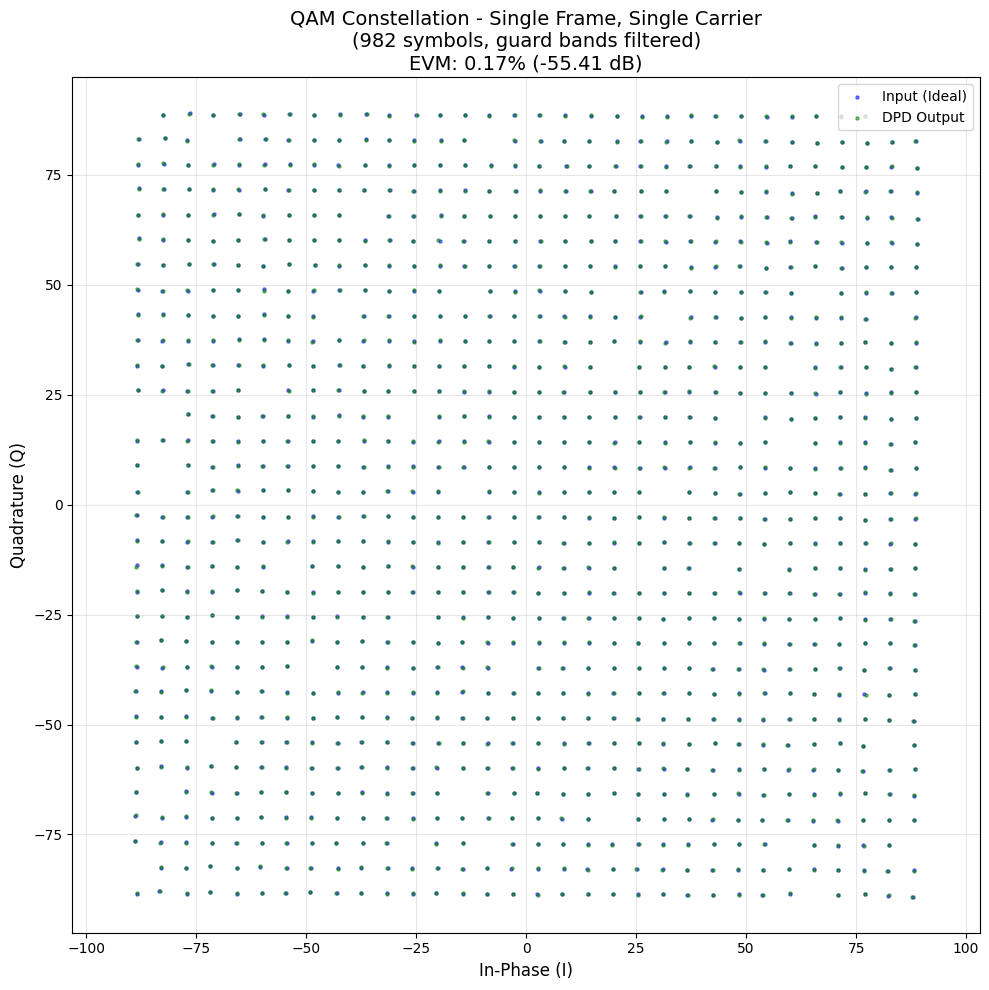

EVM (RMS): 0.170%
EVM (dB): -55.414 dB


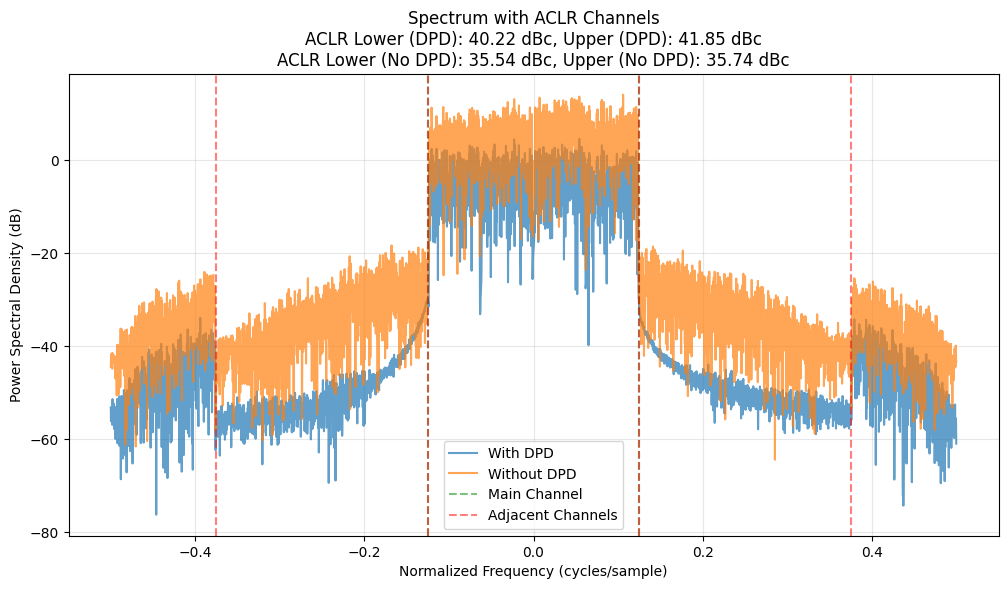

NMSE of best adaptive pruned PG-JANET model: -50.5584 dB


In [18]:
# load the adaptive best, and find its performance
best_adaptive_pruned_pgjanet_inverse_nn = PGJANET_NeuralNetwork(num_memory_levels=15, model_type='PGJANETNetwork', nn_file_path='pgjanet_one_layer_adaptive_pruned_inverse_model_open.pt', forward_model=False)
best_adaptive_pruned_pgjanet_datapath = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=best_adaptive_pruned_pgjanet_inverse_nn)
best_adaptive_pruned_pgjanet_datapath.plot_constellation(openDPD_dataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)
best_adaptive_pruned_pgjanet_datapath.plot_spectrum_with_aclr(openDPD_dataManager.test_dataset.input_data[:5000], channel_bw=0.25, channel_spacing=0.25)
print(f"NMSE of best adaptive pruned PG-JANET model: {best_adaptive_pruned_pgjanet_datapath.calculate_nmse(openDPD_dataManager.test_dataset.input_data):.4f} dB")

# ARVTDNN one layer

Using cuda device
Epoch  10/80  Loss=1.0751e+01  Valid Loss=8.1082e+03  LR=1.00e-03
Epoch  20/80  Loss=5.4274e+00  Valid Loss=6.0197e+03  LR=1.00e-03
Epoch  30/80  Loss=3.3272e+00  Valid Loss=4.2040e+03  LR=1.00e-03
Epoch  40/80  Loss=2.0282e+00  Valid Loss=2.2914e+03  LR=1.00e-03
Epoch  50/80  Loss=1.3211e+00  Valid Loss=1.3253e+03  LR=1.00e-03
Epoch  60/80  Loss=1.1474e+00  Valid Loss=1.1681e+03  LR=1.00e-03
Epoch  70/80  Loss=9.7593e-01  Valid Loss=1.1195e+03  LR=1.00e-03
Epoch  80/80  Loss=1.0738e+00  Valid Loss=1.0977e+03  LR=1.00e-03

Best model from epoch 80 with validation loss: 1.0977e+03
Iteration 1/30 (Block 1/1, samples 0-294912) - NMSE: -5.5287 dB
--------------------------------------------------
Epoch  10/80  Loss=6.0566e-01  Valid Loss=2.8567e+01  LR=1.00e-03
Epoch  20/80  Loss=5.8895e-01  Valid Loss=2.2000e+01  LR=1.00e-03
Epoch  30/80  Loss=5.8760e-01  Valid Loss=1.9683e+01  LR=1.00e-03
Epoch  40/80  Loss=5.8729e-01  Valid Loss=1.8464e+01  LR=1.00e-03
Epoch  50/80  Lo

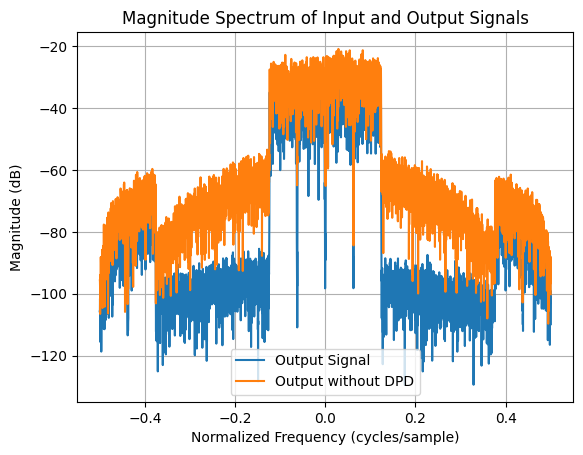

In [6]:
# Train an inverse model based on this forward model
# Instantiate a new PNTDNN model for training (one layer)

ARVTDNN_inverse_nn = ARVTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path=None, forward_model=False)
# Create a datapath with this model and the forward model
datapath_arvtdnn_one_layer = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=ARVTDNN_inverse_nn)

datapath_arvtdnn_one_layer.train_using_ila(
    training_dataset = openDPD_dataManager.training_dataset,
    valid_dataset = openDPD_dataManager.validation_dataset,
    iterations = 30,
    retrain_epochs_per_iteration=80,
    seq_length=None
)

# find nmse
nmse = datapath_arvtdnn_one_layer.calculate_nmse(openDPD_dataManager.test_dataset.input_data)
print(f"NMSE: {nmse:.4f} dB")

# Plot the spectrum 
datapath_arvtdnn_one_layer.plot_spectrum(openDPD_dataManager.test_dataset.input_data[:5000])

# write to file 
ARVTDNN_inverse_nn.write_nn_to_file('arvtdnn_inverse_model_open.pt')

Using cuda device
Raw PA Output (no DPD):
Total subcarriers (1 carrier): 1024, Active (after guard band filtering): 982


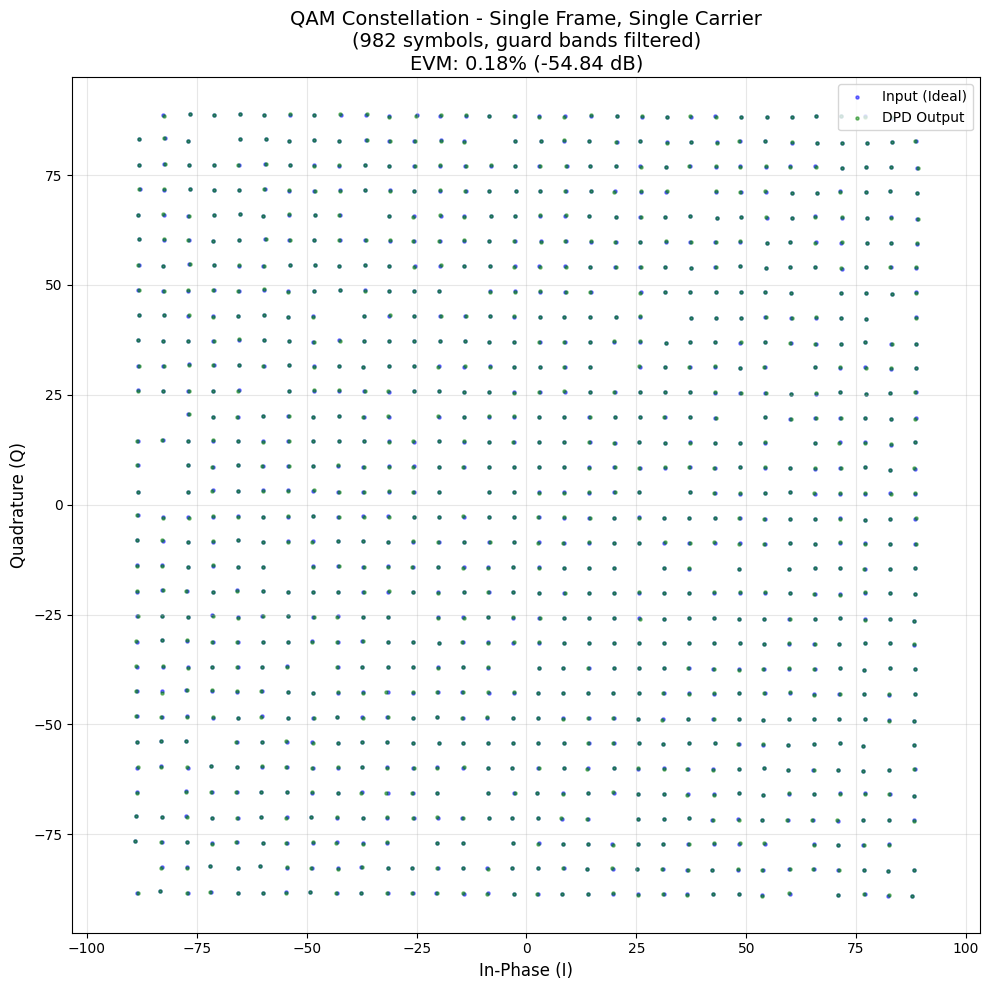

EVM (RMS): 0.181%
EVM (dB): -54.842 dB


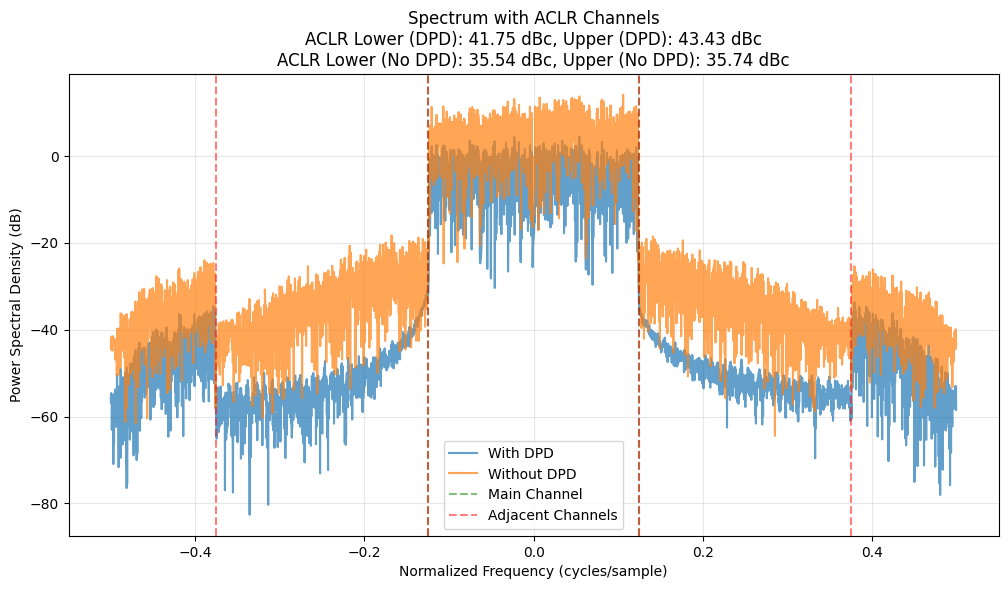

NMSE: (No DPD) 5.7197 dB
NMSE: -50.9195 dB


In [34]:
ARVTDNN_inverse_nn = ARVTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path='arvtdnn_inverse_model_open.pt', forward_model=False)
datapath_arvtdnn_one_layer = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=ARVTDNN_inverse_nn)

# Evaluate model performance before pruning
openDPD_fs = 640e6  # Sampling frequency: 640 MHz
openDPD_bw_main_ch = 160e6  # Main channel bandwidth: 160 MHz
openDPD_bw_sub_ch = 40e6  # Sub-channel bandwidth: 40 MHz
openDPD_n_sub_ch = 4  # Number of sub-channels
openDPD_nperseg = 16384  # FFT size (frame length)

# Plot the QAM constellation - First check raw PA output (should be distorted)
print("Raw PA Output (no DPD):")
datapath_arvtdnn_one_layer.plot_constellation(openDPD_dataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)

datapath_arvtdnn_one_layer.plot_spectrum_with_aclr(
    openDPD_dataManager.test_dataset.input_data[:5000],
    channel_bw=0.25,
    channel_spacing=0.25
)

print(f"NMSE: (No DPD) {openDPD_dataManager.test_dataset.calculate_nmse():.4f} dB")
print(f"NMSE: {datapath_arvtdnn_one_layer.calculate_nmse(openDPD_dataManager.test_dataset.input_data):.4f} dB")


Pruning Iteration 1/10
Pruning 20.0% of remaining weights...
Current pruning: 20.03% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=2.3382e-02  Valid Loss=1.4144e+01  LR=1.00e-03
Epoch  20/100  Loss=2.4889e-02  Valid Loss=1.3621e+01  LR=1.00e-03
Epoch  30/100  Loss=3.2366e-02  Valid Loss=1.3291e+01  LR=1.00e-03
Epoch  40/100  Loss=3.1748e-02  Valid Loss=1.3399e+01  LR=1.00e-03
Epoch  50/100  Loss=2.1474e-02  Valid Loss=1.3358e+01  LR=1.00e-03
Epoch  60/100  Loss=2.0619e-02  Valid Loss=1.3378e+01  LR=1.00e-03
Epoch  70/100  Loss=1.4962e-02  Valid Loss=1.2950e+01  LR=5.00e-04
Epoch  80/100  Loss=1.5059e-02  Valid Loss=1.2975e+01  LR=2.50e-04
Epoch  90/100  Loss=1.4677e-02  Valid Loss=1.2845e+01  LR=2.50e-04
Epoch 100/100  Loss=1.4798e-02  Valid Loss=1.2814e+01  LR=2.50e-04

Best model from epoch 100 with validation loss: 1.2814e+01
Iteration 1/3 (Block 1/1, samples 0-294912) - NMSE: -48.6750 dB
--------------------------------------------------
Epoch  10/100  Loss=

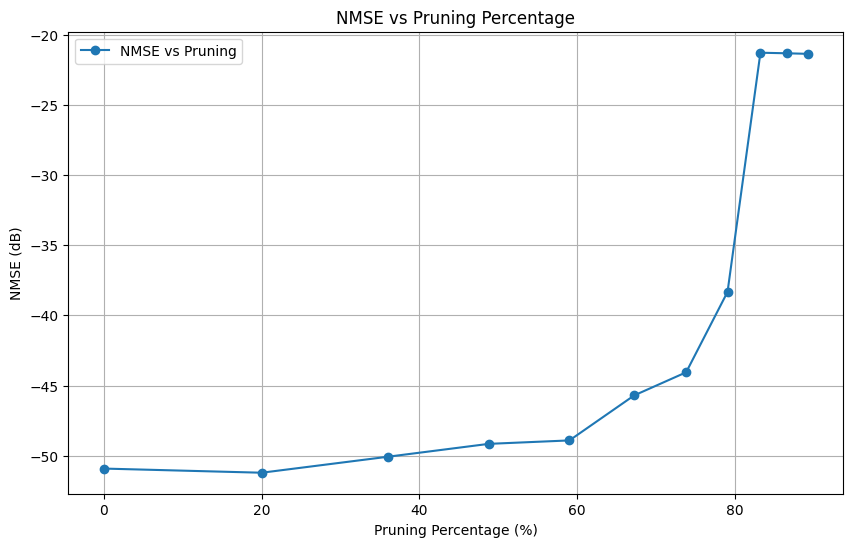

In [35]:
# Now prune the inverse model and evaluate performance again
pruning_experiment_arvtdnn_one_layer = DatapathPruningExperiment(
    datapath=datapath_arvtdnn_one_layer,
    training_dataset=openDPD_dataManager.training_dataset,
    validation_dataset=openDPD_dataManager.validation_dataset,
    test_dataset=openDPD_dataManager.test_dataset,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=100,
    ila_iterations=3,
    nmse_tolerance=-40,
    seq_length=None
)

pruning_experiment_arvtdnn_one_layer.run()

# Save the best linear pruned inverse model
pruning_experiment_arvtdnn_one_layer.best_datapath.inverse_model.write_nn_to_file('arvtdnn_one_layer_fixed_percentage_pruned_inverse_model_open.pt')


Using cuda device
Sparsity of pruned model: 0.00%
Total subcarriers (1 carrier): 1024, Active (after guard band filtering): 982


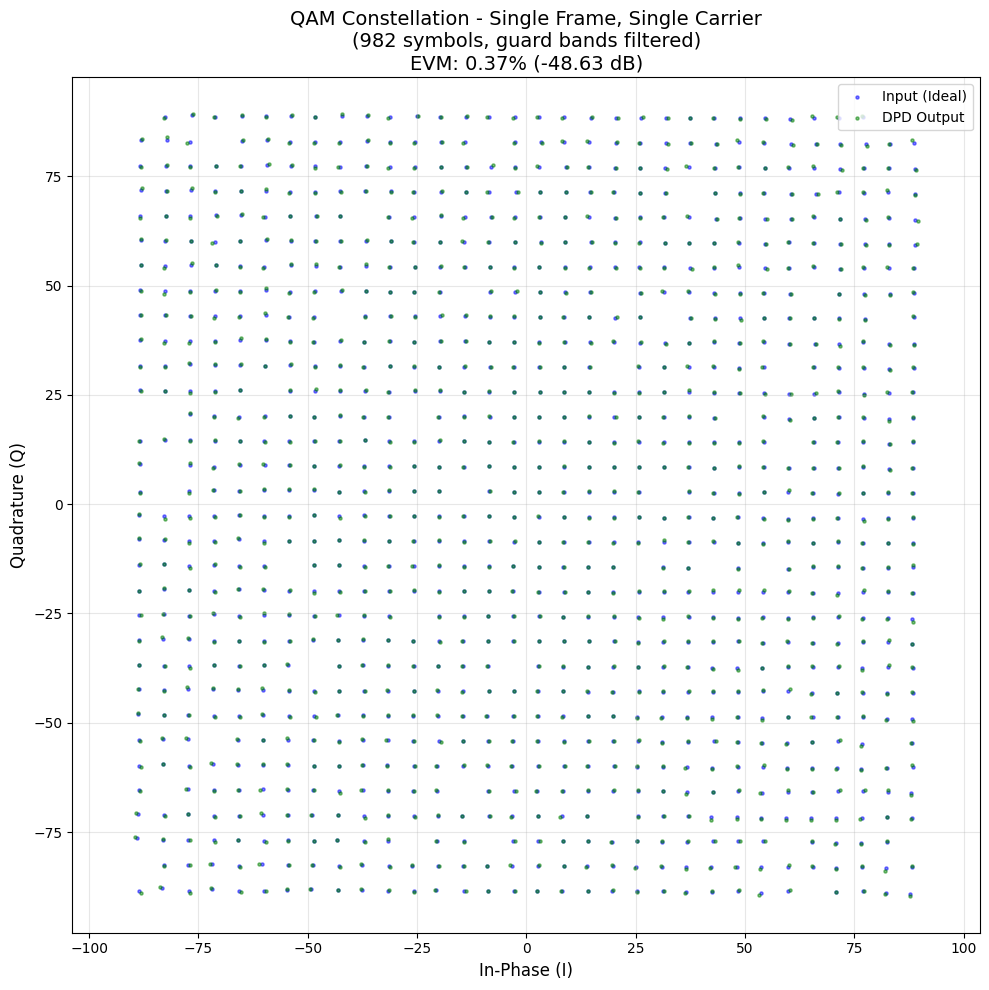

EVM (RMS): 0.370%
EVM (dB): -48.630 dB


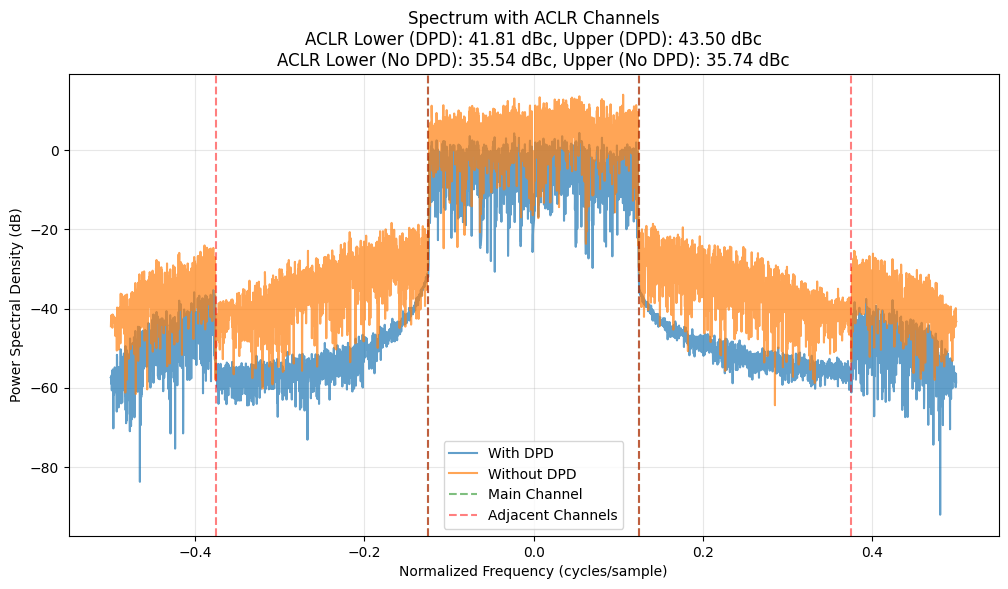

In [36]:
# Load best linear pruned model and evaluate performance
best_pruned_inverse_nn = ARVTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path='arvtdnn_one_layer_fixed_percentage_pruned_inverse_model_open.pt', forward_model=False)
#print sparsity of pruned model
print(f"Sparsity of pruned model: {best_pruned_inverse_nn._get_pruning_percentage():.2f}%")

best_pruned_datapath = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=best_pruned_inverse_nn)
# Plots for of best model
best_pruned_datapath.plot_constellation(openDPD_dataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)
best_pruned_datapath.plot_spectrum_with_aclr(openDPD_dataManager.test_dataset.input_data[:5000], channel_bw=0.25, channel_spacing=0.25)


Step 1  |  fraction = 20.00%
Pruning 20.00% of remaining weights...
Current sparsity: 20.03% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=2.3382e-02  Valid Loss=1.4144e+01  LR=1.00e-03
Epoch  20/100  Loss=2.4889e-02  Valid Loss=1.3621e+01  LR=1.00e-03
Epoch  30/100  Loss=3.2366e-02  Valid Loss=1.3291e+01  LR=1.00e-03
Epoch  40/100  Loss=3.1748e-02  Valid Loss=1.3399e+01  LR=1.00e-03
Epoch  50/100  Loss=2.1474e-02  Valid Loss=1.3358e+01  LR=1.00e-03
Epoch  60/100  Loss=2.0619e-02  Valid Loss=1.3378e+01  LR=1.00e-03
Epoch  70/100  Loss=1.4962e-02  Valid Loss=1.2950e+01  LR=5.00e-04
Epoch  80/100  Loss=1.5059e-02  Valid Loss=1.2975e+01  LR=2.50e-04
Epoch  90/100  Loss=1.4677e-02  Valid Loss=1.2845e+01  LR=2.50e-04
Epoch 100/100  Loss=1.4798e-02  Valid Loss=1.2814e+01  LR=2.50e-04

Best model from epoch 100 with validation loss: 1.2814e+01
Iteration 1/3 (Block 1/1, samples 0-294912) - NMSE: -48.6750 dB
--------------------------------------------------
Epoch  10/10

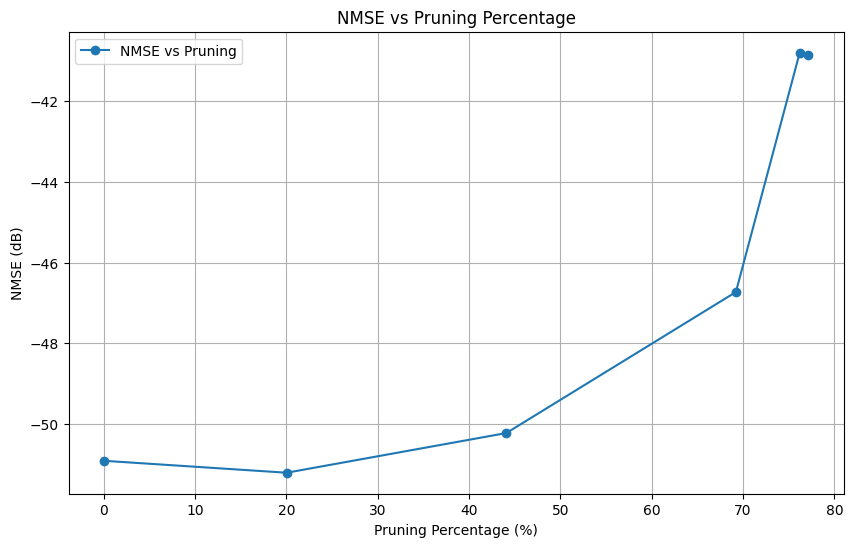

Best NMSE after pruning: -40.8553 dB


In [37]:
# Now try an adaptive pruning approach


adaptive_pruning_experiment = AdaptiveDatapathPruningExperiment(
    datapath=datapath_arvtdnn_one_layer,
    training_dataset=openDPD_dataManager.training_dataset,
    validation_dataset=openDPD_dataManager.validation_dataset,
    test_dataset=openDPD_dataManager.test_dataset,
    retrain_epochs=100,
    ila_iterations = 3,
    initial_prune_fraction=0.2,
    max_prune_fraction=0.5,
    min_prune_fraction=0.01,
    nmse_tolerance=10.9195
)

adaptive_pruning_experiment.run()

print("Best NMSE after pruning: {:.4f} dB".format(adaptive_pruning_experiment.best_datapath.calculate_nmse(openDPD_dataManager.test_dataset.input_data)))

Using cuda device
Total subcarriers (1 carrier): 1024, Active (after guard band filtering): 982


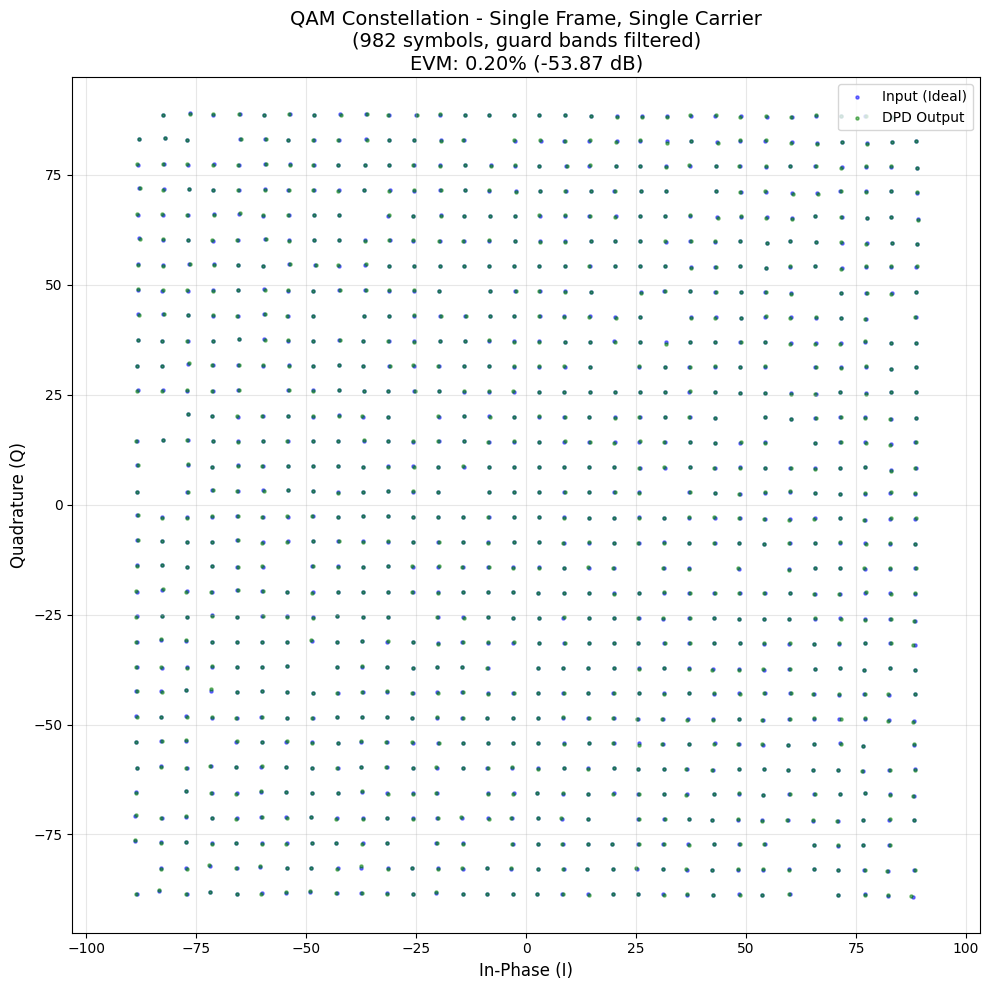

EVM (RMS): 0.203%
EVM (dB): -53.867 dB


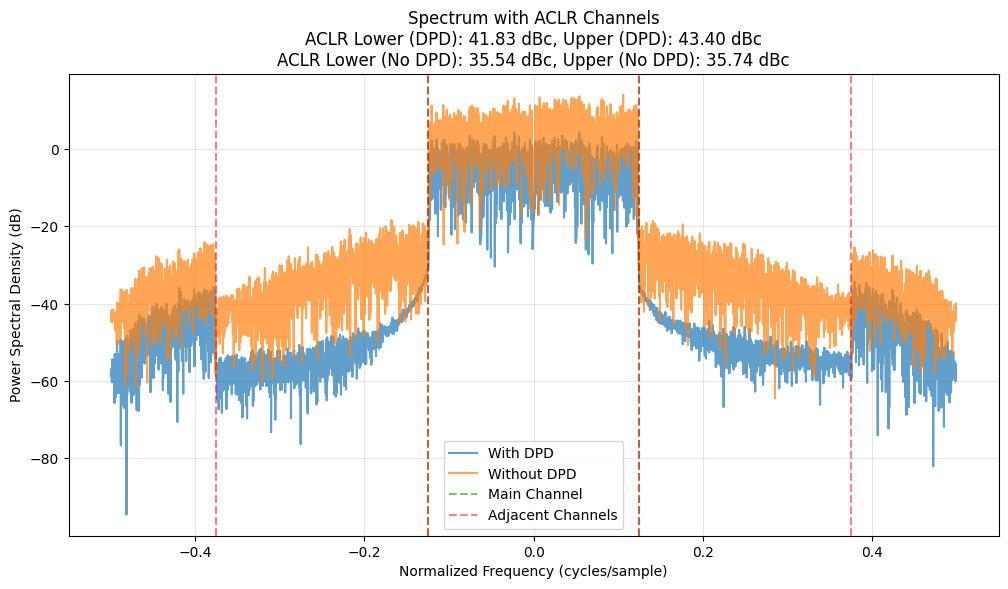

In [19]:
# load the adaptive best, and find its performance
best_adaptive_pruned_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path='pntdnn_one_layer_adaptive_pruned_inverse_model_open.pt', forward_model=False)
best_adaptive_pruned_datapath = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=best_adaptive_pruned_inverse_nn)
best_adaptive_pruned_datapath.plot_constellation(openDPD_dataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)
best_adaptive_pruned_datapath.plot_spectrum_with_aclr(openDPD_dataManager.test_dataset.input_data[:5000], channel_bw=0.25, channel_spacing=0.25)

# PNTDNN Two Layer

Using cuda device
Epoch  10/50  Loss=1.4160e+01  Valid Loss=1.0890e+03  LR=1.00e-03
Epoch  20/50  Loss=1.0634e+01  Valid Loss=6.0050e+02  LR=1.00e-03
Epoch  30/50  Loss=7.7956e+00  Valid Loss=3.3641e+02  LR=1.00e-03
Epoch  40/50  Loss=6.6746e+00  Valid Loss=2.6541e+02  LR=1.00e-03
Epoch  50/50  Loss=6.0495e+00  Valid Loss=2.3720e+02  LR=1.00e-03

Best model from epoch 49 with validation loss: 2.3716e+02
Iteration 1/25 (Block 1/1, samples 0-294912) - NMSE: -2.9125 dB
--------------------------------------------------
Epoch  10/50  Loss=2.6358e+00  Valid Loss=1.4724e+03  LR=1.00e-03
Epoch  20/50  Loss=2.2052e+00  Valid Loss=1.2528e+03  LR=5.00e-04
Epoch  30/50  Loss=2.0689e+00  Valid Loss=1.1118e+03  LR=2.50e-04
Epoch  40/50  Loss=2.0071e+00  Valid Loss=1.0553e+03  LR=1.25e-04
Epoch  50/50  Loss=1.9738e+00  Valid Loss=1.0177e+03  LR=6.25e-05

Best model from epoch 2 with validation loss: 9.7118e+02
Iteration 2/25 (Block 1/1, samples 0-294912) - NMSE: -6.5101 dB
--------------------------

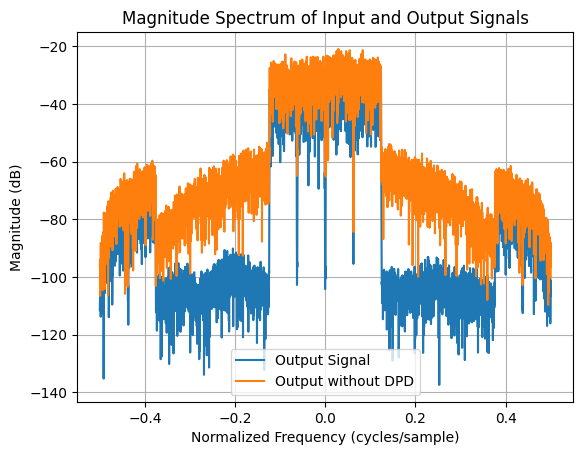

In [ ]:
# Train an inverse model based on this forward model
# Instantiate a new PNTDNN model for training (two layers)

PNTDNN_three_layer_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='ThreeLayerNetwork', nn_file_path=None, forward_model=False)
# Create a datapath with this model and the forward model
datapath_pntdnn_three_layer = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=PNTDNN_three_layer_inverse_nn)

datapath_pntdnn_three_layer.train_using_ila(
    training_dataset = openDPD_dataManager.training_dataset,
    valid_dataset = openDPD_dataManager.validation_dataset,
    iterations = 25,
    retrain_epochs_per_iteration=50,
    seq_length=None
)

# find nmse
nmse = datapath_pntdnn_three_layer.calculate_nmse(openDPD_dataManager.test_dataset.input_data)
print(f"NMSE: {nmse:.4f} dB")

# Plot the spectrum 
datapath_pntdnn_three_layer.plot_spectrum(openDPD_dataManager.test_dataset.input_data[:5000])

# Save model
datapath_pntdnn_three_layer.inverse_model.write_nn_to_file('pntdnn_three_layer_inverse_model_open.pt')

Using cuda device
Raw PA Output (no DPD):
Total subcarriers (1 carrier): 1024, Active (after guard band filtering): 982


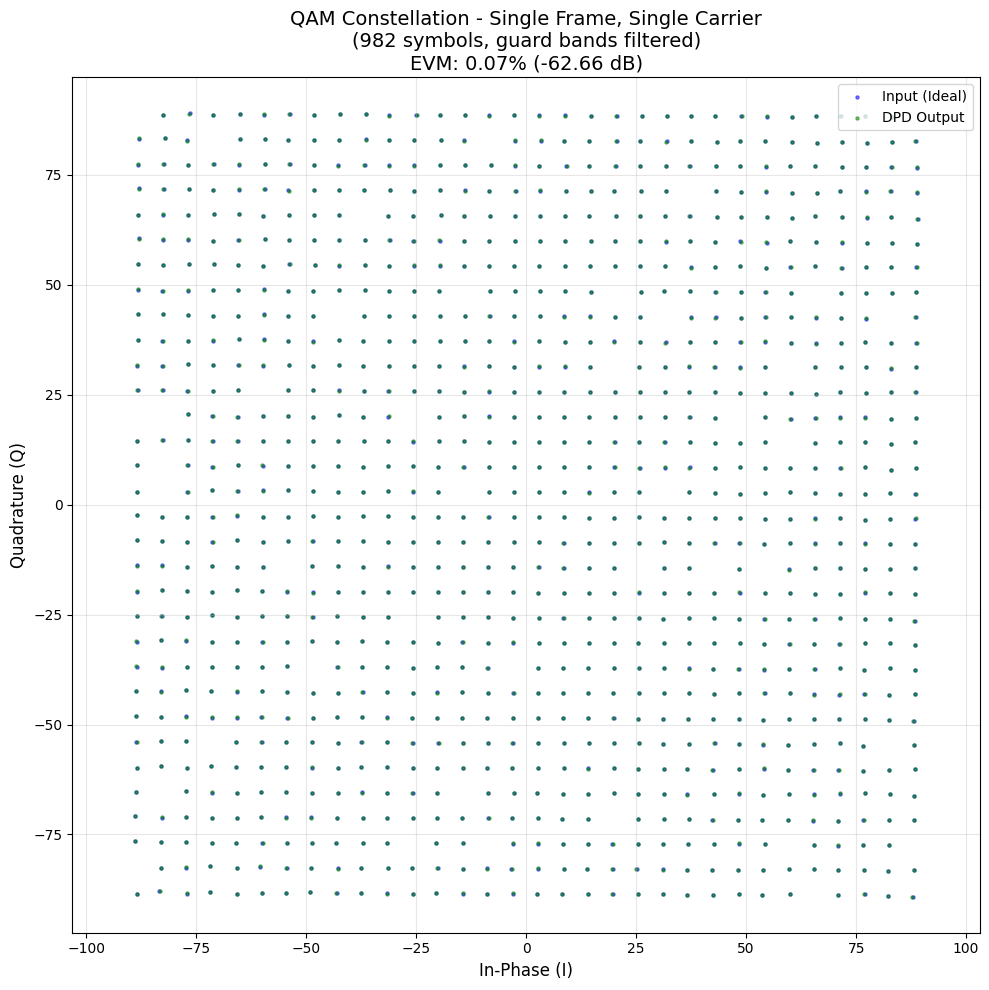

EVM (RMS): 0.074%
EVM (dB): -62.664 dB


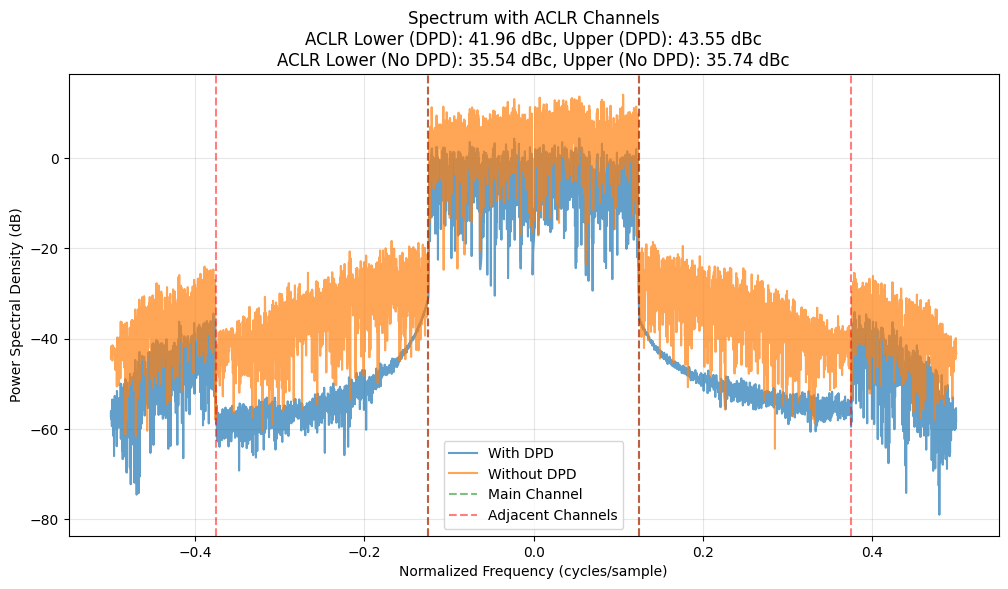

NMSE: (No DPD) 5.7197 dB
NMSE: -55.7729 dB


In [29]:
PNTDNN_three_layer_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='ThreeLayerNetwork', nn_file_path='pntdnn_three_layer_inverse_model_open.pt', forward_model=False)
datapath_pntdnn_three_layer = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=PNTDNN_three_layer_inverse_nn)

# Evaluate model performance before pruning
openDPD_fs = 640e6  # Sampling frequency: 640 MHz
openDPD_bw_main_ch = 160e6  # Main channel bandwidth: 160 MHz
openDPD_bw_sub_ch = 40e6  # Sub-channel bandwidth: 40 MHz
openDPD_n_sub_ch = 4  # Number of sub-channels
openDPD_nperseg = 16384  # FFT size (frame length)

# Plot the QAM constellation - First check raw PA output (should be distorted)
print("Raw PA Output (no DPD):")
datapath_pntdnn_three_layer.plot_constellation(openDPD_dataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)

datapath_pntdnn_three_layer.plot_spectrum_with_aclr(
    openDPD_dataManager.test_dataset.input_data[:5000],
    channel_bw=0.25,
    channel_spacing=0.25
)

print(f"NMSE: (No DPD) {openDPD_dataManager.test_dataset.calculate_nmse():.4f} dB")
print(f"NMSE: {datapath_pntdnn_three_layer.calculate_nmse(openDPD_dataManager.test_dataset.input_data):.4f} dB")


Pruning Iteration 1/10
Pruning 20.0% of remaining weights...
Current pruning: 20.00% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=3.7353e-02  Valid Loss=4.2829e+01  LR=1.00e-03
Epoch  20/100  Loss=8.0095e-02  Valid Loss=4.1475e+01  LR=1.00e-03
Epoch  30/100  Loss=3.1626e-02  Valid Loss=4.1593e+01  LR=1.00e-03
Epoch  40/100  Loss=4.1577e-02  Valid Loss=4.0807e+01  LR=1.00e-03
Epoch  50/100  Loss=3.2637e-02  Valid Loss=4.0368e+01  LR=1.00e-03
Epoch  60/100  Loss=2.4999e-02  Valid Loss=4.0087e+01  LR=5.00e-04
Epoch  70/100  Loss=2.4581e-02  Valid Loss=3.9550e+01  LR=2.50e-04
Epoch  80/100  Loss=2.4463e-02  Valid Loss=3.9250e+01  LR=1.25e-04
Epoch  90/100  Loss=2.4304e-02  Valid Loss=3.9020e+01  LR=6.25e-05
Epoch 100/100  Loss=2.4305e-02  Valid Loss=3.8846e+01  LR=6.25e-05

Best model from epoch 100 with validation loss: 3.8846e+01
Iteration 1/1 (Block 1/1, samples 0-294912) - NMSE: -51.2432 dB
--------------------------------------------------
NMSE: -51.0669 dB

P

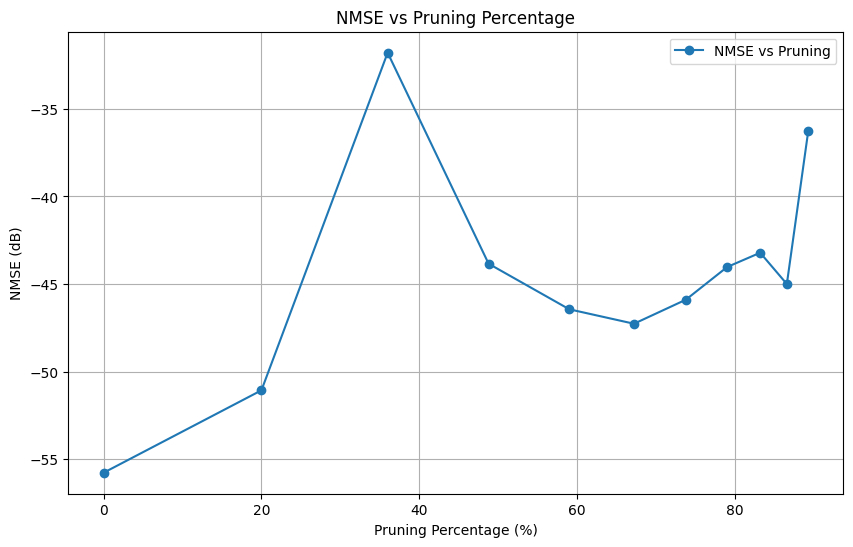

In [4]:
# Now prune the inverse model and evaluate performance again
pruning_experiment_pntdnn_three_layer = DatapathPruningExperiment(
    datapath=datapath_pntdnn_three_layer,
    training_dataset=openDPD_dataManager.training_dataset,
    validation_dataset=openDPD_dataManager.validation_dataset,
    test_dataset=openDPD_dataManager.test_dataset,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=100,
    ila_iterations=1,
    nmse_tolerance=-40,
    seq_length=None
)

pruning_experiment_pntdnn_three_layer.run()

# Save the best linear pruned inverse model
pruning_experiment_pntdnn_three_layer.best_datapath.inverse_model.write_nn_to_file('pntdnn_three_layer_fixed_percentage_pruned_inverse_model_open.pt')


Using cuda device
Sparsity of pruned model: 0.00%
Total subcarriers (1 carrier): 1024, Active (after guard band filtering): 982


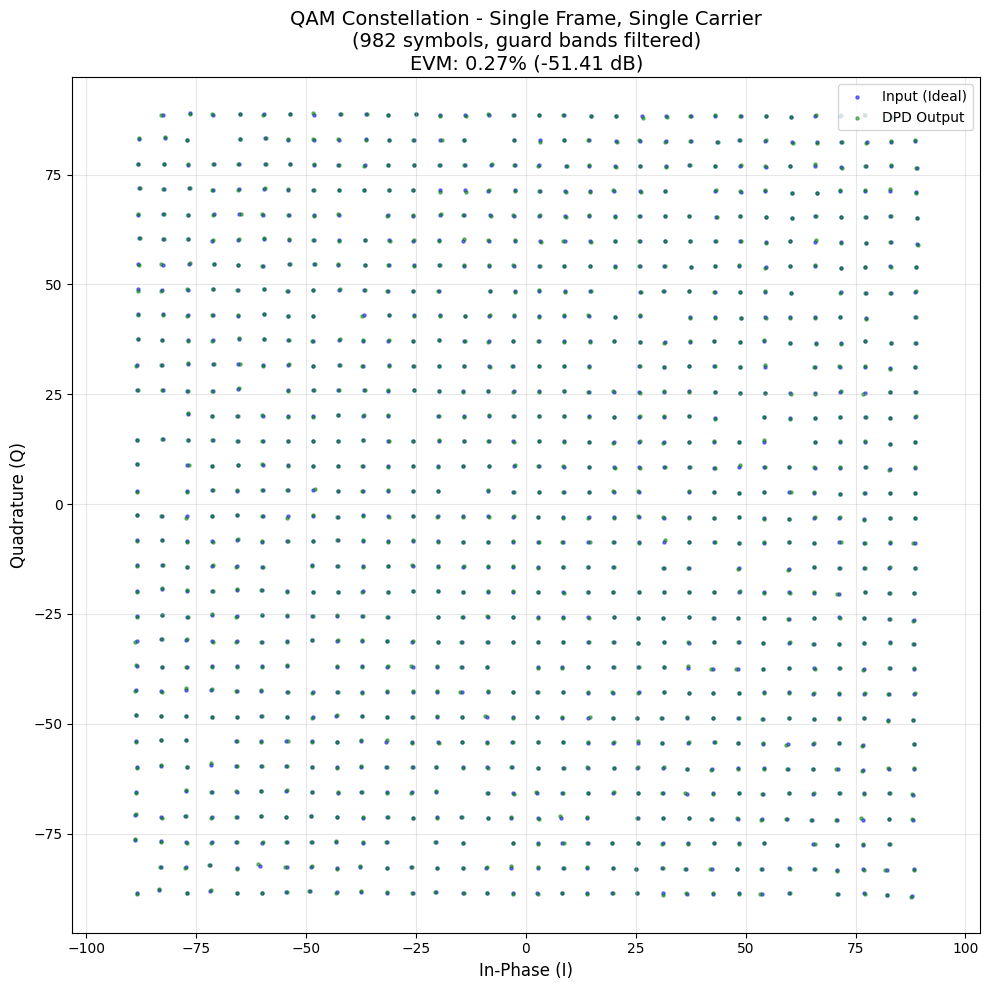

EVM (RMS): 0.269%
EVM (dB): -51.407 dB


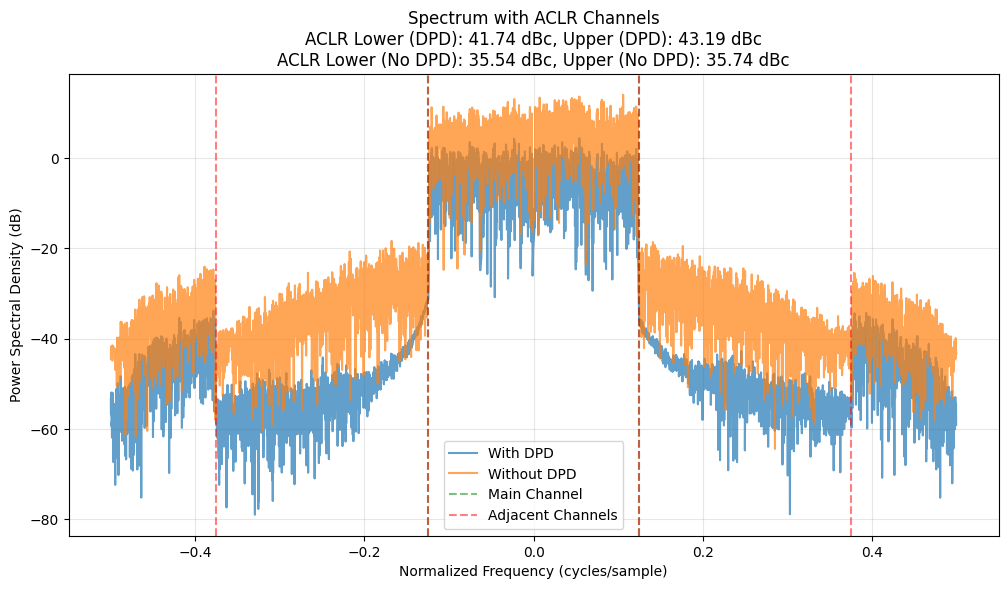

NMSE of best pruned model: -44.9978 dB


In [31]:
# Find EVM and ACLR of best pruned model
best_pruned_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='ThreeLayerNetwork', nn_file_path='pntdnn_three_layer_fixed_percentage_pruned_inverse_model_open.pt', forward_model=False)
print(f"Sparsity of pruned model: {best_pruned_inverse_nn._get_pruning_percentage():.2f}%")
best_pruned_datapath = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=best_pruned_inverse_nn)
best_pruned_datapath.plot_constellation(openDPD_dataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)
best_pruned_datapath.plot_spectrum_with_aclr(openDPD_dataManager.test_dataset.input_data[:5000], channel_bw=0.25, channel_spacing=0.25)
print(f"NMSE of best pruned model: {best_pruned_datapath.calculate_nmse(openDPD_dataManager.test_dataset.input_data):.4f} dB")


Step 1  |  fraction = 50.00%
Pruning 50.00% of remaining weights...
Current sparsity: 50.00% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=1.7066e-01  Valid Loss=4.2084e+01  LR=1.00e-03
Epoch  20/100  Loss=1.4549e-01  Valid Loss=4.2298e+01  LR=1.00e-03
Epoch  30/100  Loss=1.1311e-01  Valid Loss=4.2492e+01  LR=5.00e-04
Epoch  40/100  Loss=1.0676e-01  Valid Loss=4.2935e+01  LR=2.50e-04
Epoch  50/100  Loss=1.0494e-01  Valid Loss=4.2931e+01  LR=1.25e-04
Epoch  60/100  Loss=1.0398e-01  Valid Loss=4.2938e+01  LR=6.25e-05
Epoch  70/100  Loss=1.0357e-01  Valid Loss=4.2865e+01  LR=3.13e-05
Epoch  80/100  Loss=1.0333e-01  Valid Loss=4.2850e+01  LR=1.56e-05
Epoch  90/100  Loss=1.0314e-01  Valid Loss=4.2866e+01  LR=7.81e-06
Epoch 100/100  Loss=1.0305e-01  Valid Loss=4.2861e+01  LR=3.91e-06

Best model from epoch 22 with validation loss: 4.1841e+01
Iteration 1/3 (Block 1/1, samples 0-294912) - NMSE: -46.9351 dB
--------------------------------------------------
Epoch  10/100

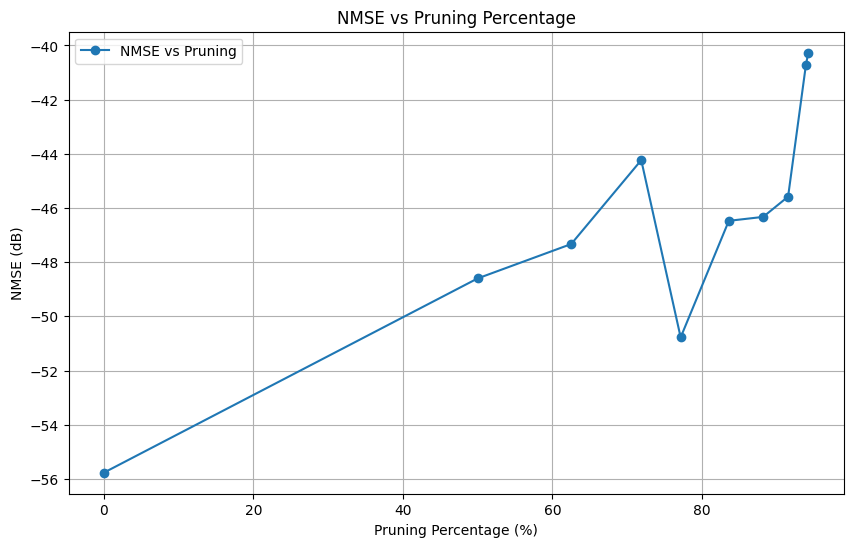

In [32]:
# Adaptive pruning for three layer model
adaptive_pruning_pntdnn_three_layer_experiment = AdaptiveDatapathPruningExperiment(
    datapath=datapath_pntdnn_three_layer,
    training_dataset=openDPD_dataManager.training_dataset,
    validation_dataset=openDPD_dataManager.validation_dataset,
    test_dataset=openDPD_dataManager.test_dataset,
    retrain_epochs=100,
    ila_iterations = 3,
    initial_prune_fraction=0.5,
    max_prune_fraction=0.5,
    min_prune_fraction=0.01,
    nmse_tolerance=15.7729
)

adaptive_pruning_pntdnn_three_layer_experiment.run()

#write best adaptive pruned model to file
adaptive_pruning_pntdnn_three_layer_experiment.best_datapath.inverse_model.write_nn_to_file('pntdnn_three_layer_adaptive_pruned_inverse_model_open.pt')

Using cuda device
Total subcarriers (1 carrier): 1024, Active (after guard band filtering): 982


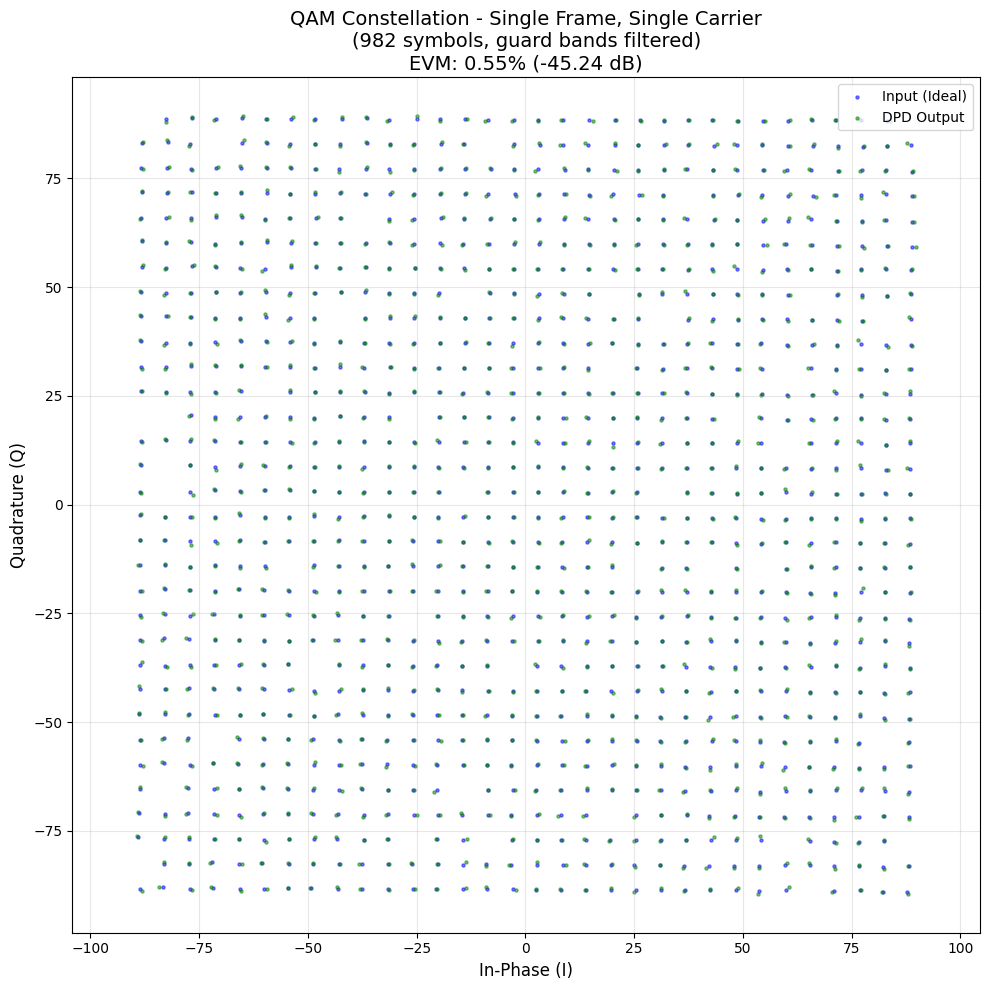

EVM (RMS): 0.547%
EVM (dB): -45.242 dB


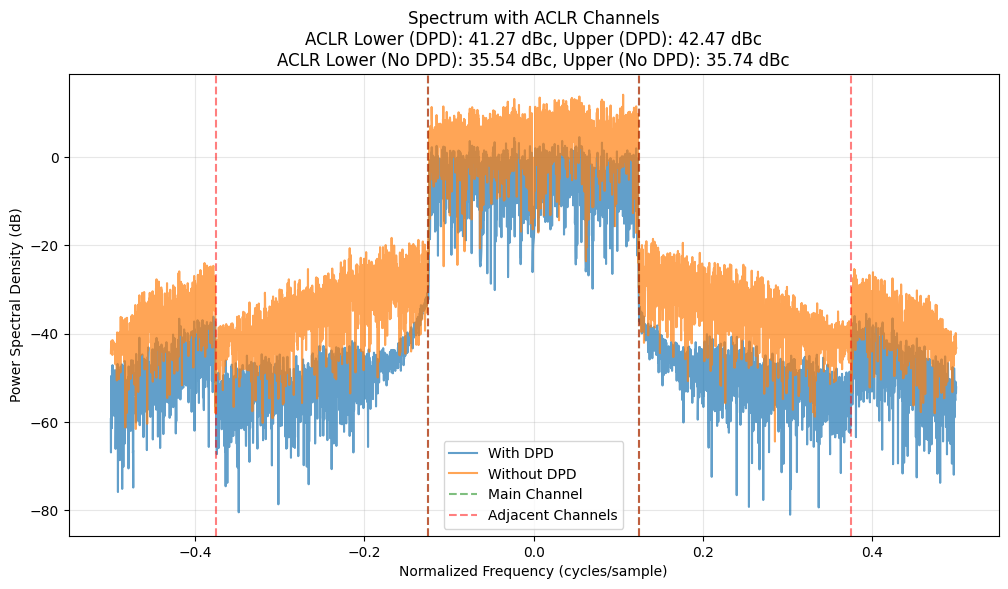

NMSE of best adaptive pruned model: -40.2696 dB


In [33]:
# load the adaptive best, and find its performance
best_adaptive_pruned_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='ThreeLayerNetwork', nn_file_path='pntdnn_three_layer_adaptive_pruned_inverse_model_open.pt', forward_model=False)
best_adaptive_pruned_datapath = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=best_adaptive_pruned_inverse_nn)
best_adaptive_pruned_datapath.plot_constellation(openDPD_dataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)
best_adaptive_pruned_datapath.plot_spectrum_with_aclr(openDPD_dataManager.test_dataset.input_data[:5000], channel_bw=0.25, channel_spacing=0.25)
print(f"NMSE of best adaptive pruned model: {best_adaptive_pruned_datapath.calculate_nmse(openDPD_dataManager.test_dataset.input_data):.4f} dB")